In [1]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("behavior-in-the-wild/LAMBDA")

df_train = ds["train"].to_pandas()
df_test = ds["test"].to_pandas()

df = pd.concat([df_train, df_test], ignore_index=True)
df.head()


ad_details_df = pd.DataFrame(df["ad_details"].tolist())
df_new = pd.concat([df.drop(columns=["ad_details"]), ad_details_df], axis=1)
df_new.head()

df_audio = df_new[["video_id", "recall_score", "youtube_id", "Audio"]].copy()
#df_audio = df_audio.rename(columns={"Audio": "audio"})
df_audio.head()


C:\Users\Thao\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,video_id,recall_score,youtube_id,Audio
0,1437,0.33,fjE8uCbWEhQ,
1,37,0.80,3DK8I80Yhgs,"Two full meals, $5.99 each. Marparoya, crispy ..."
2,1806,0.86,epvlMnOO3Ew,"Zsem tolik preponenta sebohhooztih, kar povaja..."
3,1055,0.57,2ZsxgpRMBDg,"Who doesn't dream about having smooth, silky, ..."
4,1839,0.33,QVfj-EYnZ6s,


In [2]:
pip install langdetect

Note: you may need to restart the kernel to use updated packages.


In [3]:
from langdetect import detect_langs, DetectorFactory
import pandas as pd
import numpy as np

DetectorFactory.seed = 42

# Nếu cột tên là "audio" thì dùng audio, nếu là "Audio" thì dùng Audio
audio_col = "audio" if "audio" in df_audio.columns else "Audio"

df_audio_check = df_audio.copy()

# Chuyển audio về string, nhưng giữ NaN để check chuẩn
df_audio_check[audio_col] = df_audio_check[audio_col].astype("string")

# Các giá trị được coi là không có thông tin
no_info_values = [
    "",
    "nan",
    "none",
    "null",
    "na",
    "n/a",
    "not found",
    "no info",
    "no information",
    "no audio",
    "blank"
]

def check_audio_info(text):
    # Nếu là NaN thật
    if pd.isna(text):
        return "blank_no_info"
    
    text_clean = str(text).strip().lower()
    
    # Nếu rỗng hoặc nằm trong list no info
    if text_clean in no_info_values:
        return "blank_no_info"
    
    return "has_info"

df_audio_check["audio_info_status"] = df_audio_check[audio_col].apply(check_audio_info)

info_summary = (
    df_audio_check["audio_info_status"]
    .value_counts()
    .reset_index()
)

info_summary.columns = ["audio_info_status", "count"]

info_summary["percentage"] = (
    info_summary["count"] / info_summary["count"].sum() * 100
).round(2)

info_summary

,audio_info_status,count,percentage
0,has_info,1235,56.57
1,blank_no_info,948,43.43


In [4]:
from langdetect import detect_langs, DetectorFactory
import pandas as pd

DetectorFactory.seed = 42

# Chọn đúng tên cột audio
audio_col = "audio" if "audio" in df_audio_check.columns else "Audio"

def detect_english_or_not(text):
    text = str(text).strip()
    
    try:
        detected = detect_langs(text)
        best_lang = detected[0].lang
        best_prob = detected[0].prob
        
        if best_lang == "en" and best_prob >= 0.70:
            return "english"
        else:
            return "not_english"
            
    except:
        return "not_english"

# Chỉ detect trong những dòng có info
mask_has_info = df_audio_check["audio_info_status"] == "has_info"

df_audio_check.loc[mask_has_info, "audio_language_group"] = (
    df_audio_check.loc[mask_has_info, audio_col].apply(detect_english_or_not)
)

# Summary chỉ trong những dòng có info
language_summary_has_info = (
    df_audio_check.loc[mask_has_info, "audio_language_group"]
    .value_counts()
    .reset_index()
)

language_summary_has_info.columns = ["audio_language_group", "count"]

language_summary_has_info["percentage_among_has_info"] = (
    language_summary_has_info["count"] 
    / language_summary_has_info["count"].sum() * 100
).round(2)

language_summary_has_info

,audio_language_group,count,percentage_among_has_info
0,english,1137,92.06
1,not_english,98,7.94


In [5]:
# Chọn đúng tên cột audio
audio_col = "audio" if "audio" in df_audio_check.columns else "Audio"

# Tạo bảng mới chỉ gồm dòng có info + tiếng Anh
df_audio_en = df_audio_check[
    (df_audio_check["audio_info_status"] == "has_info") &
    (df_audio_check["audio_language_group"] == "english")
][["video_id", "youtube_id", "recall_score", audio_col]].copy()

# Đổi tên cột audio về chữ thường cho dễ dùng sau này
df_audio_en = df_audio_en.rename(columns={audio_col: "audio"})

# Reset index
df_audio_en = df_audio_en.reset_index(drop=True)

df_audio_en.head()

,video_id,youtube_id,recall_score,audio
0,37,3DK8I80Yhgs,0.80,"Two full meals, $5.99 each. Marparoya, crispy ..."
1,1055,2ZsxgpRMBDg,0.57,"Who doesn't dream about having smooth, silky, ..."
2,761,00STtvbodn8,0.43,"When you shop at Burlington, you'll find the l..."
3,2383,lgskk192v8Q,1.00,It's time that I told you the story of Aladdin...
4,2084,pdsBuJu7fnQ,1.00,You might be interested to know that your vehi...


In [6]:
df_audio_en.describe()

,video_id,recall_score
count,1137.000000,1137.000000
mean,1365.331574,0.618417
std,784.348327,0.284487
min,1.000000,0.000000
25%,781.000000,0.430000
50%,1389.000000,0.670000
75%,2041.000000,0.860000
max,2711.000000,1.000000


In [7]:
pip install torch 

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install transformers huggingface_hub

Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
import numpy as np
import re
import torch
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader, TensorDataset
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

In [11]:
df_model = df_audio_en.copy()
#make sure input str/float
df_model["audio"] = df_model["audio"].astype(str)
df_model["recall_score"] = df_model["recall_score"].astype(float)
df_model = df_model[["video_id", "youtube_id", "recall_score", "audio"]].copy()

df_model.head()

,video_id,youtube_id,recall_score,audio
0,37,3DK8I80Yhgs,0.80,"Two full meals, $5.99 each. Marparoya, crispy ..."
1,1055,2ZsxgpRMBDg,0.57,"Who doesn't dream about having smooth, silky, ..."
2,761,00STtvbodn8,0.43,"When you shop at Burlington, you'll find the l..."
3,2383,lgskk192v8Q,1.00,It's time that I told you the story of Aladdin...
4,2084,pdsBuJu7fnQ,1.00,You might be interested to know that your vehi...


In [12]:
#text cleaning
def clean_text_basic(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s\$\.\%]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_model["audio_clean"] = df_model["audio"].apply(clean_text_basic)

df_model[["audio", "audio_clean"]].head()

,audio,audio_clean
0,"Two full meals, $5.99 each. Marparoya, crispy ...",two full meals $5.99 each. marparoya crispy tw...
1,"Who doesn't dream about having smooth, silky, ...",who doesn t dream about having smooth silky to...
2,"When you shop at Burlington, you'll find the l...",when you shop at burlington you ll find the la...
3,It's time that I told you the story of Aladdin...,it s time that i told you the story of aladdin...
4,You might be interested to know that your vehi...,you might be interested to know that your vehi...


In [13]:
train_val_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (727, 5)
Validation: (182, 5)
Test: (228, 5)


In [14]:
def evaluate_regression(y_true, y_pred, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    if np.std(y_pred) == 0 or np.std(y_true) == 0:
        pearson = np.nan
        spearman = np.nan
    else:
        pearson = pearsonr(y_true, y_pred)[0]
        spearman = spearmanr(y_true, y_pred)[0]

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Pearson": pearson,
        "Spearman": spearman
    }

In [15]:
tfidf_ridge_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        stop_words="english"
    )),
    ("ridge", Ridge(alpha=1.0))
])

tfidf_ridge_model.fit(
    train_df["audio_clean"],
    train_df["recall_score"]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of ty

In [16]:
val_preds_tfidf = tfidf_ridge_model.predict(val_df["audio_clean"])

tfidf_val_result = evaluate_regression(
    y_true=val_df["recall_score"],
    y_pred=val_preds_tfidf,
    model_name="TF-IDF + Ridge Validation"
)

tfidf_val_result

{'model': 'TF-IDF + Ridge Validation',
 'MAE': 0.23599972410023692,
 'RMSE': np.float64(0.2830982403005723),
 'R2': 0.06305496171984948,
 'Pearson': np.float64(0.26503323087008945),
 'Spearman': np.float64(0.2829093220709082)}

In [17]:
test_preds_tfidf = tfidf_ridge_model.predict(test_df["audio_clean"])

tfidf_test_result = evaluate_regression(
    y_true=test_df["recall_score"],
    y_pred=test_preds_tfidf,
    model_name="TF-IDF + Ridge Test"
)

tfidf_test_result

{'model': 'TF-IDF + Ridge Test',
 'MAE': 0.2372240097916694,
 'RMSE': np.float64(0.28646112078396674),
 'R2': 0.05786232831102067,
 'Pearson': np.float64(0.262403061829659),
 'Spearman': np.float64(0.28231717487911656)}

In [18]:
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model = bert_model.to(device)

print("Device:", device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8074.94it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cpu


In [19]:
def get_bert_embeddings(texts, batch_size=8, max_length=128):
    bert_model.eval()
    
    all_embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        
        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)
        
        with torch.no_grad():
            outputs = bert_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
        
        token_embeddings = outputs.last_hidden_state
        
      
        attention_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        
        sum_embeddings = torch.sum(token_embeddings * attention_mask_expanded, dim=1)
        sum_mask = torch.clamp(attention_mask_expanded.sum(dim=1), min=1e-9)
        
        mean_embeddings = sum_embeddings / sum_mask
        
        all_embeddings.append(mean_embeddings.cpu().numpy())
    
    all_embeddings = np.vstack(all_embeddings)
    
    return all_embeddings

In [20]:
X_train_bert = get_bert_embeddings(
    train_df["audio_clean"].tolist(),
    batch_size=8,
    max_length=128
)

X_val_bert = get_bert_embeddings(
    val_df["audio_clean"].tolist(),
    batch_size=8,
    max_length=128
)

X_test_bert = get_bert_embeddings(
    test_df["audio_clean"].tolist(),
    batch_size=8,
    max_length=128
)

y_train = train_df["recall_score"].values
y_val = val_df["recall_score"].values
y_test = test_df["recall_score"].values

print("Train embeddings:", X_train_bert.shape)
print("Validation embeddings:", X_val_bert.shape)
print("Test embeddings:", X_test_bert.shape)

Train embeddings: (727, 768)
Validation embeddings: (182, 768)
Test embeddings: (228, 768)


In [21]:
bert_linear_model = LinearRegression()

bert_linear_model.fit(X_train_bert, y_train)

val_preds_bert_linear = bert_linear_model.predict(X_val_bert)

bert_linear_val_result = evaluate_regression(
    y_true=y_val,
    y_pred=val_preds_bert_linear,
    model_name="BERT Embeddings + Linear Regression Validation"
)

bert_linear_val_result

{'model': 'BERT Embeddings + Linear Regression Validation',
 'MAE': 1.0879822714250167,
 'RMSE': np.float64(1.438077037853683),
 'R2': -23.1770929215834,
 'Pearson': np.float64(0.17395309018078078),
 'Spearman': np.float64(0.17418035053491127)}

In [22]:
test_preds_bert_linear = bert_linear_model.predict(X_test_bert)

bert_linear_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds_bert_linear,
    model_name="BERT Embeddings + Linear Regression Test"
)

bert_linear_test_result

{'model': 'BERT Embeddings + Linear Regression Test',
 'MAE': 1.100195659085324,
 'RMSE': np.float64(1.536335584139918),
 'R2': -26.099119203929124,
 'Pearson': np.float64(0.1121007896121594),
 'Spearman': np.float64(0.07385492892549642)}

In [23]:
bert_ridge_model = Ridge(alpha=1.0)

bert_ridge_model.fit(X_train_bert, y_train)

val_preds_bert_ridge = bert_ridge_model.predict(X_val_bert)

bert_ridge_val_result = evaluate_regression(
    y_true=y_val,
    y_pred=val_preds_bert_ridge,
    model_name="BERT Embeddings + Ridge Regression Validation"
)

bert_ridge_val_result

{'model': 'BERT Embeddings + Ridge Regression Validation',
 'MAE': 0.2840306729929788,
 'RMSE': np.float64(0.35003626639644014),
 'R2': -0.43240511010460314,
 'Pearson': np.float64(0.16626475802028434),
 'Spearman': np.float64(0.1616621035614124)}

In [24]:
alpha_values = [0.01, 0.1, 1.0, 10.0, 50, 100.0 , 200]

ridge_val_results = []

for alpha in alpha_values:
    model = Ridge(alpha=alpha)
    model.fit(X_train_bert, y_train)
    
    val_preds = model.predict(X_val_bert)
    
    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"BERT Embeddings + Ridge alpha={alpha}"
    )
    
    result["alpha"] = alpha
    ridge_val_results.append(result)

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values("RMSE")

,model,MAE,RMSE,R2,Pearson,Spearman,alpha
5,BERT Embeddings + Ridge alpha=100.0,0.231542,0.274915,0.116441,0.353556,0.361918,100.00
4,BERT Embeddings + Ridge alpha=50,0.230048,0.275115,0.115150,0.341595,0.349428,50.00
6,BERT Embeddings + Ridge alpha=200,0.233782,0.276977,0.103136,0.345104,0.359956,200.00
3,BERT Embeddings + Ridge alpha=10.0,0.238115,0.288675,0.025774,0.271133,0.268731,10.00
2,BERT Embeddings + Ridge alpha=1.0,0.284031,0.350036,-0.432405,0.166265,0.161662,1.00
1,BERT Embeddings + Ridge alpha=0.1,0.397427,0.508584,-2.023883,0.124522,0.107044,0.10
0,BERT Embeddings + Ridge alpha=0.01,0.614275,0.815771,-6.779943,0.140814,0.120356,0.01


In [25]:
best_alpha = ridge_val_results_df.sort_values("RMSE").iloc[0]["alpha"]

best_alpha

best_bert_ridge_model = Ridge(alpha=best_alpha)

best_bert_ridge_model.fit(X_train_bert, y_train)

best_test_preds_bert_ridge = best_bert_ridge_model.predict(X_test_bert)

best_bert_ridge_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=best_test_preds_bert_ridge,
    model_name=f"BERT Embeddings + Ridge Test alpha={best_alpha}"
)

best_bert_ridge_test_result

{'model': 'BERT Embeddings + Ridge Test alpha=100.0',
 'MAE': 0.23111260703258343,
 'RMSE': np.float64(0.27661761992465705),
 'R2': 0.12149815790614926,
 'Pearson': np.float64(0.3549980653312716),
 'Spearman': np.float64(0.3611369326780447)}

In [26]:
#distilBERT
distilbert_model_name = "distilbert-base-uncased"

distilbert_tokenizer = AutoTokenizer.from_pretrained(distilbert_model_name)
distilbert_model = AutoModel.from_pretrained(distilbert_model_name)

distilbert_model = distilbert_model.to(device)
distilbert_model.eval()


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8053.42it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=Tru

In [27]:
def get_distilbert_embeddings(texts, batch_size=8, max_length=128):
    distilbert_model.eval()
    
    all_embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        
        encoded = distilbert_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        
        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)
        
        with torch.no_grad():
            outputs = distilbert_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
        
        token_embeddings = outputs.last_hidden_state
        
        # Mean pooling, không tính padding tokens
        attention_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        
        sum_embeddings = torch.sum(token_embeddings * attention_mask_expanded, dim=1)
        sum_mask = torch.clamp(attention_mask_expanded.sum(dim=1), min=1e-9)
        
        mean_embeddings = sum_embeddings / sum_mask
        
        all_embeddings.append(mean_embeddings.cpu().numpy())
    
    all_embeddings = np.vstack(all_embeddings)
    
    return all_embeddings

In [28]:
X_train_distilbert = get_distilbert_embeddings(
    train_df["audio_clean"].tolist(),
    batch_size=8,
    max_length=128
)

X_val_distilbert = get_distilbert_embeddings(
    val_df["audio_clean"].tolist(),
    batch_size=8,
    max_length=128
)

X_test_distilbert = get_distilbert_embeddings(
    test_df["audio_clean"].tolist(),
    batch_size=8,
    max_length=128
)

y_train = train_df["recall_score"].values
y_val = val_df["recall_score"].values
y_test = test_df["recall_score"].values

print("Train embeddings:", X_train_distilbert.shape)
print("Validation embeddings:", X_val_distilbert.shape)
print("Test embeddings:", X_test_distilbert.shape)

Train embeddings: (727, 768)
Validation embeddings: (182, 768)
Test embeddings: (228, 768)


In [29]:
distilbert_linear_model = LinearRegression()

distilbert_linear_model.fit(X_train_distilbert, y_train)

val_preds_distilbert_linear = distilbert_linear_model.predict(X_val_distilbert)

distilbert_linear_val_result = evaluate_regression(
    y_true=y_val,
    y_pred=val_preds_distilbert_linear,
    model_name="distilbert Embeddings + Linear Regression Validation"
)

distilbert_linear_val_result

{'model': 'distilbert Embeddings + Linear Regression Validation',
 'MAE': 0.9501892865359128,
 'RMSE': np.float64(1.3458743858259623),
 'R2': -20.176239089753274,
 'Pearson': np.float64(0.02007275001850097),
 'Spearman': np.float64(0.07610258076602994)}

In [30]:
test_preds_distilbert_linear = distilbert_linear_model.predict(X_test_distilbert)

distilbert_linear_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds_distilbert_linear,
    model_name="distilbert Embeddings + Linear Regression Test"
)

distilbert_linear_test_result

{'model': 'distilbert Embeddings + Linear Regression Test',
 'MAE': 0.97727826411264,
 'RMSE': np.float64(1.300572297649475),
 'R2': -18.420123815839695,
 'Pearson': np.float64(0.16556177960754745),
 'Spearman': np.float64(0.1575312167859651)}

In [31]:
distilbert_ridge_model = Ridge(alpha=1.0)

distilbert_ridge_model.fit(X_train_distilbert, y_train)

val_preds_distilbert_ridge = distilbert_ridge_model.predict(X_val_distilbert)

distilbert_ridge_val_result = evaluate_regression(
    y_true=y_val,
    y_pred=val_preds_distilbert_ridge,
    model_name="distilbert Embeddings + Ridge Regression Validation"
)

distilbert_ridge_val_result

{'model': 'distilbert Embeddings + Ridge Regression Validation',
 'MAE': 0.28563874271544776,
 'RMSE': np.float64(0.34365783111558107),
 'R2': -0.38067755780801993,
 'Pearson': np.float64(0.002143172160352837),
 'Spearman': np.float64(-0.017364729743617555)}

In [32]:
distilbert_results = []

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200]:
    model = Ridge(alpha=alpha)
    model.fit(X_train_distilbert, y_train)
    
    val_preds = model.predict(X_val_distilbert)
    
    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"DistilBERT Embeddings + Ridge Validation alpha={alpha}"
    )
    
    distilbert_results.append(result)

distilbert_results_df = pd.DataFrame(distilbert_results)
distilbert_results_df.sort_values("RMSE", ascending=True)

,model,MAE,RMSE,R2,Pearson,Spearman
4,DistilBERT Embeddings + Ridge Validation alpha...,0.233973,0.276934,0.103413,0.338232,0.349666
3,DistilBERT Embeddings + Ridge Validation alpha...,0.233419,0.277295,0.101073,0.321890,0.323553
5,DistilBERT Embeddings + Ridge Validation alpha...,0.235859,0.278494,0.093286,0.335144,0.345264
2,DistilBERT Embeddings + Ridge Validation alpha...,0.242815,0.290839,0.011120,0.204926,0.201485
1,DistilBERT Embeddings + Ridge Validation alpha...,0.285639,0.343658,-0.380678,0.002143,-0.017365
0,DistilBERT Embeddings + Ridge Validation alpha...,0.364183,0.459837,-1.471991,-0.044183,-0.060601


In [33]:
pd.set_option("display.max_colwidth", None)

distilbert_results_df.sort_values("RMSE", ascending=True)

,model,MAE,RMSE,R2,Pearson,Spearman
4,DistilBERT Embeddings + Ridge Validation alpha=100.0,0.233973,0.276934,0.103413,0.338232,0.349666
3,DistilBERT Embeddings + Ridge Validation alpha=50.0,0.233419,0.277295,0.101073,0.321890,0.323553
5,DistilBERT Embeddings + Ridge Validation alpha=200,0.235859,0.278494,0.093286,0.335144,0.345264
2,DistilBERT Embeddings + Ridge Validation alpha=10.0,0.242815,0.290839,0.011120,0.204926,0.201485
1,DistilBERT Embeddings + Ridge Validation alpha=1.0,0.285639,0.343658,-0.380678,0.002143,-0.017365
0,DistilBERT Embeddings + Ridge Validation alpha=0.1,0.364183,0.459837,-1.471991,-0.044183,-0.060601


In [34]:
best_model = Ridge(alpha=100)
best_model.fit(X_train_distilbert, y_train)

test_preds = best_model.predict(X_test_distilbert)

distilbert_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds,
    model_name=f"DistilBERT Embeddings + Ridge Test alpha={100}"
)

distilbert_test_result

{'model': 'DistilBERT Embeddings + Ridge Test alpha=100',
 'MAE': 0.23292434809500706,
 'RMSE': np.float64(0.27558063311239456),
 'R2': 0.12807248424108608,
 'Pearson': np.float64(0.377204915321929),
 'Spearman': np.float64(0.38252948262820796)}

In [35]:
#RoBERTa

model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
roberta_model = AutoModel.from_pretrained(model_name)

roberta_model = roberta_model.to(device)
roberta_model.eval()

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7443.81it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=Tru

In [36]:
def get_roberta_embeddings(texts, batch_size=8, max_length=128):
    roberta_model.eval()
    
    all_embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        
        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)
        
        with torch.no_grad():
            outputs = roberta_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
        
        token_embeddings = outputs.last_hidden_state
        
        attention_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * attention_mask_expanded, dim=1)
        sum_mask = torch.clamp(attention_mask_expanded.sum(dim=1), min=1e-9)
        mean_embeddings = sum_embeddings / sum_mask
        
        all_embeddings.append(mean_embeddings.cpu().numpy())
    
    return np.vstack(all_embeddings)

In [37]:
X_train_roberta = get_roberta_embeddings(
    train_df["audio_clean"].tolist(),
    batch_size=8,
    max_length=128
)

X_val_roberta = get_roberta_embeddings(
    val_df["audio_clean"].tolist(),
    batch_size=8,
    max_length=128
)

X_test_roberta = get_roberta_embeddings(
    test_df["audio_clean"].tolist(),
    batch_size=8,
    max_length=128
)

y_train = train_df["recall_score"].values
y_val = val_df["recall_score"].values
y_test = test_df["recall_score"].values

print("Train embeddings:", X_train_roberta.shape)
print("Validation embeddings:", X_val_roberta.shape)
print("Test embeddings:", X_test_roberta.shape)

Train embeddings: (727, 768)
Validation embeddings: (182, 768)
Test embeddings: (228, 768)


In [38]:
roberta_linear_model = LinearRegression()

roberta_linear_model.fit(X_train_roberta, y_train)

val_preds_roberta_linear = roberta_linear_model.predict(X_val_roberta)

roberta_linear_val_result = evaluate_regression(
    y_true=y_val,
    y_pred=val_preds_roberta_linear,
    model_name="roberta Embeddings + Linear Regression Validation"
)

roberta_linear_val_result

{'model': 'roberta Embeddings + Linear Regression Validation',
 'MAE': 1.1742581647307009,
 'RMSE': np.float64(1.4734737110263678),
 'R2': -24.38192517809126,
 'Pearson': np.float64(0.09568047289779973),
 'Spearman': np.float64(0.09876483820946562)}

In [39]:
test_preds_roberta_linear = roberta_linear_model.predict(X_test_roberta)

roberta_linear_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds_roberta_linear,
    model_name="roberta Embeddings + Linear Regression Test"
)

roberta_linear_test_result

{'model': 'roberta Embeddings + Linear Regression Test',
 'MAE': 1.1497026629196971,
 'RMSE': np.float64(1.5921129301458843),
 'R2': -28.10252928097701,
 'Pearson': np.float64(-0.04670649119294514),
 'Spearman': np.float64(-0.016594130585583223)}

In [40]:
roberta_ridge_model = Ridge(alpha=1.0)

roberta_ridge_model.fit(X_train_roberta, y_train)

val_preds_roberta_ridge = roberta_ridge_model.predict(X_val_roberta)

roberta_ridge_val_result = evaluate_regression(
    y_true=y_val,
    y_pred=val_preds_roberta_ridge,
    model_name="roberta Embeddings + Ridge Regression Validation"
)

roberta_ridge_val_result

{'model': 'roberta Embeddings + Ridge Regression Validation',
 'MAE': 0.236603223491501,
 'RMSE': np.float64(0.2928005961813973),
 'R2': -0.002267595427997815,
 'Pearson': np.float64(0.2663144983977142),
 'Spearman': np.float64(0.24585349007336058)}

In [41]:
roberta_results = []

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200]:
    model = Ridge(alpha=alpha)
    model.fit(X_train_roberta, y_train)
    
    val_preds = model.predict(X_val_roberta)
    
    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"roberta Embeddings + Ridge Validation alpha={alpha}"
    )
    
    roberta_results.append(result)

roberta_results_df = pd.DataFrame(roberta_results)
roberta_results_df.sort_values("RMSE", ascending=True)

,model,MAE,RMSE,R2,Pearson,Spearman
2,roberta Embeddings + Ridge Validation alpha=10.0,0.231733,0.280113,0.082710,0.289921,0.290059
3,roberta Embeddings + Ridge Validation alpha=50.0,0.236635,0.281175,0.075745,0.280454,0.286752
4,roberta Embeddings + Ridge Validation alpha=100.0,0.238853,0.282700,0.065689,0.266111,0.272606
5,roberta Embeddings + Ridge Validation alpha=200,0.240765,0.284364,0.054656,0.248974,0.257763
1,roberta Embeddings + Ridge Validation alpha=1.0,0.236603,0.292801,-0.002268,0.266314,0.245853
0,roberta Embeddings + Ridge Validation alpha=0.1,0.277859,0.354497,-0.469142,0.211930,0.213308


In [42]:
best_model = Ridge(alpha=10)
best_model.fit(X_train_roberta, y_train)

test_preds = best_model.predict(X_test_roberta)

roberta_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds,
    model_name=f"roberta Embeddings + Ridge Test alpha={10}"
)

roberta_test_result

{'model': 'roberta Embeddings + Ridge Test alpha=10',
 'MAE': 0.23819222939119,
 'RMSE': np.float64(0.28566247470039663),
 'R2': 0.06310831545036222,
 'Pearson': np.float64(0.264763025600444),
 'Spearman': np.float64(0.2847038397565554)}

In [43]:
#all-MiniLM-L6-v2
from sentence_transformers import SentenceTransformer

minilm_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8353.73it/s]


In [44]:
pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [45]:
X_train_minilm = minilm_model.encode(
    train_df["audio_clean"].fillna("").astype(str).tolist(),
    batch_size=8,
    show_progress_bar=True
)

X_val_minilm = minilm_model.encode(
    val_df["audio_clean"].fillna("").astype(str).tolist(),
    batch_size=8,
    show_progress_bar=True
)

X_test_minilm = minilm_model.encode(
    test_df["audio_clean"].fillna("").astype(str).tolist(),
    batch_size=8,
    show_progress_bar=True
)

y_train = train_df["recall_score"].astype(float).values
y_val = val_df["recall_score"].astype(float).values
y_test = test_df["recall_score"].astype(float).values

print("Train embeddings:", X_train_minilm.shape)
print("Validation embeddings:", X_val_minilm.shape)
print("Test embeddings:", X_test_minilm.shape)

Batches: 100%|██████████| 29/29 [00:00<00:00, 36.28it/s]

Train embeddings: (727, 384)
Validation embeddings: (182, 384)
Test embeddings: (228, 384)


In [46]:
minilm_linear_model = LinearRegression()

minilm_linear_model.fit(X_train_minilm, y_train)

val_preds_minilm_linear = minilm_linear_model.predict(X_val_minilm)

minilm_linear_val_result = evaluate_regression(
    y_true=y_val,
    y_pred=val_preds_minilm_linear,
    model_name="minilm Embeddings + Linear Regression Validation"
)

minilm_linear_val_result

{'model': 'minilm Embeddings + Linear Regression Validation',
 'MAE': 0.29191763400376497,
 'RMSE': np.float64(0.3610367266909701),
 'R2': -0.5238511321157124,
 'Pearson': np.float64(0.17843472657103043),
 'Spearman': np.float64(0.17488442066907628)}

In [47]:
test_preds_minilm_linear = minilm_linear_model.predict(X_test_minilm)

minilm_linear_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds_minilm_linear,
    model_name="minilm Embeddings + Linear Regression Test"
)

minilm_linear_test_result

{'model': 'minilm Embeddings + Linear Regression Test',
 'MAE': 0.32771041999260586,
 'RMSE': np.float64(0.41213314605233586),
 'R2': -0.9501053988269856,
 'Pearson': np.float64(0.16470490838173832),
 'Spearman': np.float64(0.17232969484116384)}

In [48]:
minilm_results = []

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200.0]:
    
    model = Ridge(alpha=alpha)
    model.fit(X_train_minilm, y_train)
    
    val_preds = model.predict(X_val_minilm)
    
    result = evaluate_regression(
        y_val,
        val_preds,
        f"MiniLM Embeddings + Ridge Validation alpha={alpha}"
    )
    
    result["alpha"] = alpha
    minilm_results.append(result)

minilm_results_df = pd.DataFrame(minilm_results)
minilm_results_df = minilm_results_df.sort_values("RMSE", ascending=True)

minilm_results_df

,model,MAE,RMSE,R2,Pearson,Spearman,alpha
2,MiniLM Embeddings + Ridge Validation alpha=10.0,0.236080,0.277471,0.099930,0.351615,0.357895,10.0
1,MiniLM Embeddings + Ridge Validation alpha=1.0,0.236158,0.278552,0.092903,0.315384,0.315577,1.0
3,MiniLM Embeddings + Ridge Validation alpha=50.0,0.242752,0.284998,0.050435,0.345405,0.357352,50.0
4,MiniLM Embeddings + Ridge Validation alpha=100.0,0.245743,0.287901,0.030992,0.341806,0.353064,100.0
5,MiniLM Embeddings + Ridge Validation alpha=200.0,0.247979,0.289928,0.017302,0.339451,0.350419,200.0
0,MiniLM Embeddings + Ridge Validation alpha=0.1,0.249086,0.303607,-0.077617,0.257919,0.253148,0.1


In [49]:
best_minilm_model = Ridge(alpha=10)

best_minilm_model.fit(X_train_minilm, y_train)

minilm_test_preds = best_minilm_model.predict(X_test_minilm)

minilm_test_result = evaluate_regression(
    y_test,
    minilm_test_preds,
    f"MiniLM Embeddings + Ridge Test alpha={10}"
)

minilm_test_result

{'model': 'MiniLM Embeddings + Ridge Test alpha=10',
 'MAE': 0.23692920209022988,
 'RMSE': np.float64(0.28164010749251445),
 'R2': 0.08930699916184992,
 'Pearson': np.float64(0.3164690669597657),
 'Spearman': np.float64(0.3155888596327234)}

In [50]:
model_comparison_df = pd.DataFrame([
    best_bert_ridge_test_result,
    distilbert_test_result,
    roberta_test_result,
    minilm_test_result
])

model_comparison_df = model_comparison_df.sort_values("R2", ascending=False)

model_comparison_df

,model,MAE,RMSE,R2,Pearson,Spearman
1,DistilBERT Embeddings + Ridge Test alpha=100,0.232924,0.275581,0.128072,0.377205,0.382529
0,BERT Embeddings + Ridge Test alpha=100.0,0.231113,0.276618,0.121498,0.354998,0.361137
3,MiniLM Embeddings + Ridge Test alpha=10,0.236929,0.281640,0.089307,0.316469,0.315589
2,roberta Embeddings + Ridge Test alpha=10,0.238192,0.285662,0.063108,0.264763,0.284704


In [51]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score as recall_metric, f1_score, roc_auc_score, confusion_matrix, classification_report

# Dùng median của TRAIN để chia 2 nhóm cân bằng (~50/50)
threshold = train_df["recall_score"].median()
print(f"Threshold (median recall_score): {threshold:.3f}")

y_train_cls = (train_df["recall_score"].values >= threshold).astype(int)
y_val_cls   = (val_df["recall_score"].values   >= threshold).astype(int)
y_test_cls  = (test_df["recall_score"].values  >= threshold).astype(int)

print("verteilung (train):")
print(pd.Series(y_train_cls).value_counts(normalize=True).rename({0: "low recall", 1: "high recall"}))

Threshold (median recall_score): 0.670
verteilung (train):
high recall    0.504814
low recall     0.495186
Name: proportion, dtype: float64


In [52]:
# Logistic Regression với L2 (solver = saga)
log_reg_bert = LogisticRegression(
    solver="saga",   
    max_iter=2000,
    n_jobs=-1
)
log_reg_bert.fit(X_train_bert, y_train_cls)
train_acc = log_reg_bert.score(X_train_bert, y_train_cls)
val_acc   = log_reg_bert.score(X_val_bert, y_val_cls)

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)

C:\Users\Thao\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Train accuracy: 0.8954607977991746
Validation accuracy: 0.6043956043956044


In [53]:
y_train_pred = log_reg_bert.predict(X_train_bert)
y_val_pred   = log_reg_bert.predict(X_val_bert)

print("Train Set Performance:")
print(confusion_matrix(y_train_cls, y_train_pred))

print("\nValidation Set Performance:")
print(confusion_matrix(y_val_cls, y_val_pred))

print("\nClassification Report (Validation):")
print(classification_report(y_val_cls, y_val_pred, target_names=["low recall", "high recall"]))

Train Set Performance:
[[323  37]
 [ 39 328]]

Validation Set Performance:
[[55 33]
 [39 55]]

Classification Report (Validation):
              precision    recall  f1-score   support

  low recall       0.59      0.62      0.60        88
 high recall       0.62      0.59      0.60        94

    accuracy                           0.60       182
   macro avg       0.61      0.61      0.60       182
weighted avg       0.61      0.60      0.60       182



In [54]:
test_acc = log_reg_bert.score(X_test_bert, y_test_cls)
print("Test accuracy:", test_acc)

y_test_pred = log_reg_bert.predict(X_test_bert)
print("\nTest Set Performance:")
print(confusion_matrix(y_test_cls, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_cls, y_test_pred, target_names=["low recall", "high recall"]))

Test accuracy: 0.5964912280701754

Test Set Performance:
[[62 52]
 [40 74]]

Classification Report (Test):
              precision    recall  f1-score   support

  low recall       0.61      0.54      0.57       114
 high recall       0.59      0.65      0.62       114

    accuracy                           0.60       228
   macro avg       0.60      0.60      0.60       228
weighted avg       0.60      0.60      0.60       228



In [55]:
log_reg_distilbert = LogisticRegression(
    solver="saga",
    max_iter=2000,
    n_jobs=-1
)

log_reg_distilbert.fit(X_train_distilbert, y_train_cls)

train_acc = log_reg_distilbert.score(X_train_distilbert, y_train_cls)
val_acc   = log_reg_distilbert.score(X_val_distilbert, y_val_cls)

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)

y_train_pred = log_reg_distilbert.predict(X_train_distilbert)
y_val_pred   = log_reg_distilbert.predict(X_val_distilbert)

print("\nTrain Set Performance:")
print(confusion_matrix(y_train_cls, y_train_pred))

print("\nValidation Set Performance:")
print(confusion_matrix(y_val_cls, y_val_pred))

print("\nClassification Report (Validation):")
print(classification_report(y_val_cls, y_val_pred, target_names=["low recall", "high recall"]))

C:\Users\Thao\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Train accuracy: 0.8376891334250344
Validation accuracy: 0.5384615384615384

Train Set Performance:
[[308  52]
 [ 66 301]]

Validation Set Performance:
[[54 34]
 [50 44]]

Classification Report (Validation):
              precision    recall  f1-score   support

  low recall       0.52      0.61      0.56        88
 high recall       0.56      0.47      0.51        94

    accuracy                           0.54       182
   macro avg       0.54      0.54      0.54       182
weighted avg       0.54      0.54      0.54       182



In [56]:
log_reg_roberta = LogisticRegression(
    solver="saga",
    max_iter=2000,
    n_jobs=-1
)

log_reg_roberta.fit(X_train_roberta, y_train_cls)

train_acc = log_reg_roberta.score(X_train_roberta, y_train_cls)
val_acc   = log_reg_roberta.score(X_val_roberta, y_val_cls)

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)

y_train_pred = log_reg_roberta.predict(X_train_roberta)
y_val_pred   = log_reg_roberta.predict(X_val_roberta)

print("\nTrain Set Performance:")
print(confusion_matrix(y_train_cls, y_train_pred))

print("\nValidation Set Performance:")
print(confusion_matrix(y_val_cls, y_val_pred))

print("\nClassification Report (Validation):")
print(classification_report(y_val_cls, y_val_pred, target_names=["low recall", "high recall"]))

C:\Users\Thao\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Train accuracy: 0.8033012379642366
Validation accuracy: 0.6263736263736264

Train Set Performance:
[[298  62]
 [ 81 286]]

Validation Set Performance:
[[56 32]
 [36 58]]

Classification Report (Validation):
              precision    recall  f1-score   support

  low recall       0.61      0.64      0.62        88
 high recall       0.64      0.62      0.63        94

    accuracy                           0.63       182
   macro avg       0.63      0.63      0.63       182
weighted avg       0.63      0.63      0.63       182



In [57]:
log_reg_minilm = LogisticRegression(
    solver="saga",
    max_iter=2000,
    n_jobs=-1
)

log_reg_minilm.fit(X_train_minilm, y_train_cls)

train_acc = log_reg_minilm.score(X_train_minilm, y_train_cls)
val_acc   = log_reg_minilm.score(X_val_minilm, y_val_cls)

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)

y_train_pred = log_reg_minilm.predict(X_train_minilm)
y_val_pred   = log_reg_minilm.predict(X_val_minilm)

print("\nTrain Set Performance:")
print(confusion_matrix(y_train_cls, y_train_pred))

print("\nValidation Set Performance:")
print(confusion_matrix(y_val_cls, y_val_pred))

print("\nClassification Report (Validation):")
print(classification_report(y_val_cls, y_val_pred, target_names=["low recall", "high recall"]))

C:\Users\Thao\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Train accuracy: 0.7455295735900963
Validation accuracy: 0.6318681318681318

Train Set Performance:
[[274  86]
 [ 99 268]]

Validation Set Performance:
[[56 32]
 [35 59]]

Classification Report (Validation):
              precision    recall  f1-score   support

  low recall       0.62      0.64      0.63        88
 high recall       0.65      0.63      0.64        94

    accuracy                           0.63       182
   macro avg       0.63      0.63      0.63       182
weighted avg       0.63      0.63      0.63       182



In [58]:
def test_logistic_model(model, X_test, model_name):
    test_acc = model.score(X_test, y_test_cls)
    y_test_pred = model.predict(X_test)
    
    print(f"=== {model_name} — Test ===")
    print("Test accuracy:", test_acc)
    print(confusion_matrix(y_test_cls, y_test_pred))
    print(classification_report(y_test_cls, y_test_pred, target_names=["low recall", "high recall"]))
    print()


test_logistic_model(log_reg_distilbert, X_test_distilbert, "DistilBERT")
test_logistic_model(log_reg_roberta, X_test_roberta, "RoBERTa")
test_logistic_model(log_reg_minilm, X_test_minilm, "MiniLM")

=== DistilBERT — Test ===
Test accuracy: 0.5877192982456141
[[62 52]
 [42 72]]
              precision    recall  f1-score   support

  low recall       0.60      0.54      0.57       114
 high recall       0.58      0.63      0.61       114

    accuracy                           0.59       228
   macro avg       0.59      0.59      0.59       228
weighted avg       0.59      0.59      0.59       228


=== RoBERTa — Test ===
Test accuracy: 0.5745614035087719
[[57 57]
 [40 74]]
              precision    recall  f1-score   support

  low recall       0.59      0.50      0.54       114
 high recall       0.56      0.65      0.60       114

    accuracy                           0.57       228
   macro avg       0.58      0.57      0.57       228
weighted avg       0.58      0.57      0.57       228


=== MiniLM — Test ===
Test accuracy: 0.6359649122807017
[[69 45]
 [38 76]]
              precision    recall  f1-score   support

  low recall       0.64      0.61      0.62       114
 high

In [59]:
#BERT Test accuracy: 0.5964912280701754

#Test Set Performance:
#[[62 52]
 #[40 74]]

#Classification Report (Test):
#              precision    recall  f1-score   support

#  low recall       0.61      0.54      0.57       114
# high recall       0.59      0.65      0.62       114

#    accuracy                           0.60       228
#   macro avg       0.60      0.60      0.60       228
#weighted avg       0.60      0.60      0.60       228


In [60]:
#| Modell     | Accuracy | Durchschnittlicher F1 
#| MiniLM     | 0.636    | **0.64**              
#| BERT       | 0.596    |0.60                  
#| DistilBERT | 0.588    |0.59                  
#| RoBERTa    | 0.575    |0.57                  


In [61]:
X_train_distilbert

array([[-0.06266918,  0.20617008,  0.11421449, ...,  0.01046783,
         0.21428217, -0.02635075],
       [ 0.13388975,  0.04720735,  0.40780574, ..., -0.18440028,
         0.19600694, -0.27116477],
       [ 0.03670025,  0.09837518,  0.5012043 , ...,  0.09900843,
         0.09980186, -0.03978073],
       ...,
       [ 0.07640375, -0.00369437,  0.3953097 , ...,  0.03605777,
         0.11097442,  0.09907204],
       [-0.13182002,  0.29354   ,  0.36447716, ..., -0.30701378,
        -0.15349144, -0.11142287],
       [ 0.48498914, -0.1274072 ,  0.6544698 , ..., -0.09014641,
        -0.22863555,  0.07482247]], shape=(727, 768), dtype=float32)

In [62]:
df_new.head()

video_id  recall_score   youtube_id  \
0      1437          0.33  fjE8uCbWEhQ   
1        37          0.80  3DK8I80Yhgs   
2      1806          0.86  epvlMnOO3Ew   
3      1055          0.57  2ZsxgpRMBDg   
4      1839          0.33  QVfj-EYnZ6s   

                                                                                                                                                                                                                                                                                                                                                                                                          Audio  \
0                                                                                                                                                                                                                                                                                                                                                                                                                 
1                                                                                                                                                                                                                                      Two full meals, $5.99 each. Marparoya, crispy two fries, two drinks. Double them up or mix and match. Whatever you want, we're into that. BK, having your way. You rule!   
2                                                                               Zsem tolik preponenta sebohhooztih, kar povaja veliko zodu, ker je niregulelji. Okayorganizacije ambolizacije ujeva za obsaljajstvo odbiav steaka sgetom sunom. Sami letenje so raje v sno  k izbiljstvenega pletinnega izgledova. S other technologij sem noves bulik okalju. Na zaetek MME rijeli ti ne nemajo preizvoenstva,   
3  Who doesn't dream about having smooth, silky, touchable hair? Well now, dreams do come true. Smooth, sexy hair with its essential ingredient of coconut oil contain the most unruly of locks. Phase out frizz and embrace your sleek and sexy side. This complete system of shampoo, conditioner, blow-dry extender and finishing products will keep your moves smooth day after day. Get sexy smooth today.   
4                                                                                                                                                                                                                                                                                                                                                                                                                 

                    Brand   Duration Orientation    Pace  \
0  Mondelez International  54 second   landscape     low   
1             Burger King  15 second   landscape  medium   
2                   Xerox  33 second   landscape     low   
3             Ulta Beauty  39 second   landscape     low   
4              Albertsons  52 second      square     low   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [63]:
df_new.info()


<class 'pandas.DataFrame'>
RangeIndex: 2183 entries, 0 to 2182
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   video_id      2183 non-null   int64  
 1   recall_score  2183 non-null   float64
 2   youtube_id    2183 non-null   str    
 3   Audio         2183 non-null   str    
 4   Brand         2183 non-null   str    
 5   Duration      2183 non-null   str    
 6   Orientation   2183 non-null   str    
 7   Pace          2183 non-null   str    
 8   Scenes        2183 non-null   object 
 9   Title         2183 non-null   str    
dtypes: float64(1), int64(1), object(1), str(7)
memory usage: 1.3+ MB


In [64]:
df_audio_en.head()

,video_id,youtube_id,recall_score,audio
0,37,3DK8I80Yhgs,0.80,"Two full meals, $5.99 each. Marparoya, crispy two fries, two drinks. Double them up or mix and match. Whatever you want, we're into that. BK, having your way. You rule!"
1,1055,2ZsxgpRMBDg,0.57,"Who doesn't dream about having smooth, silky, touchable hair? Well now, dreams do come true. Smooth, sexy hair with its essential ingredient of coconut oil contain the most unruly of locks. Phase out frizz and embrace your sleek and sexy side. This complete system of shampoo, conditioner, blow-dry extender and finishing products will keep your moves smooth day after day. Get sexy smooth today."
2,761,00STtvbodn8,0.43,"When you shop at Burlington, you'll find the latest looks, the hottest styles, the brands you love. At prices so low, you'll want it all. Burlington gives you incredible deals and amazing brands and styles at everyday low prices. It's simple. At Burlington, you get a lot for a lot less. You'll love the deals. You'll love Burlington."
3,2383,lgskk192v8Q,1.00,It's time that I told you the story of Aladdin the princess and the lamp You stumbled upon an opportunity your life begins now Do you trust me You
4,2084,pdsBuJu7fnQ,1.00,"You might be interested to know that your vehicle may have a rear view mirror that allows for greater adjustability, so you can position it to your comfort for enhanced visibility. Let me explain. Your vehicle's rear view mirror has two pivot points, one at the rear of the mirror housing and one at the windshield. To adjust the mirror stem, grab a hold of the mirror housing and with a little pressure, pull down to lower and push up to raise. It can also be pivoted side to side. The mirror housing can also be adjusted left or right and tilted up or down with a little pressure. It's that simple. Any questions? Go to Owner.Ford.com. Thanks for watching. Visit www.Ford.com to learn more."


In [65]:
df_audio_en.info()

<class 'pandas.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   video_id      1137 non-null   int64  
 1   youtube_id    1137 non-null   str    
 2   recall_score  1137 non-null   float64
 3   audio         1137 non-null   string 
dtypes: float64(1), int64(1), str(1), string(1)
memory usage: 429.1 KB


In [66]:
df_model = df_audio_en.merge(
    df_new[
        [
            "video_id",
            "youtube_id",
            "Brand",
            "Duration",
            "Orientation",
            "Pace",
            "Scenes",
            "Title"
        ]
    ],
    on=["video_id", "youtube_id"],
    how="left"
)

In [67]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   video_id      1137 non-null   int64  
 1   youtube_id    1137 non-null   str    
 2   recall_score  1137 non-null   float64
 3   audio         1137 non-null   string 
 4   Brand         1137 non-null   str    
 5   Duration      1137 non-null   str    
 6   Orientation   1137 non-null   str    
 7   Pace          1137 non-null   str    
 8   Scenes        1137 non-null   object 
 9   Title         1137 non-null   str    
dtypes: float64(1), int64(1), object(1), str(6), string(1)
memory usage: 882.2+ KB


In [68]:
df_model.head()


video_id   youtube_id  recall_score  \
0        37  3DK8I80Yhgs          0.80   
1      1055  2ZsxgpRMBDg          0.57   
2       761  00STtvbodn8          0.43   
3      2383  lgskk192v8Q          1.00   
4      2084  pdsBuJu7fnQ          1.00   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  audio  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              Two full meals, $5.99 each. Marparoya, crispy two fries, two drinks. Double them up or mix and match. Whatever you want, we're into that. BK, having your way. You rule!   
1                                                                                                                                                                                                                                                                                                          Who doesn't dream about having smooth, silky, touchable hair? Well now, dreams do come true. Smooth, sexy hair with its essential ingredient of coconut oil contain the most unruly of locks. Phase out frizz and embrace your sleek and sexy side. This complete system of shampoo, conditioner, blow-dry extender and finishing products will keep your moves smooth day after day. Get sexy smooth today.   
2                                                                                                                                                                                                                                                                                                                                                                        When you shop at Burlington, you'll find the latest looks, the hottest styles, the brands you love. At prices so low, you'll want it all. Burlington gives you incredible deals and amazing brands and styles at everyday low prices. It's simple. At Burlington, you get a lot for a lot less. You'll love the deals. You'll love Burlington.   
3                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    It's time that I told you the story of Aladdin the princess and the lamp You stumbled upon an opportunity your life begins now Do you trust me You   
4  You might be interested to know that your vehicle may have a rear view mirror that allows for greater adjustability, so you can position it to your comfort for enhanced visibility. Let me explain. Your vehicle's rear view mirror has two pivot points, o

In [69]:
df_model.columns.tolist()

['video_id',
 'youtube_id',
 'recall_score',
 'audio',
 'Brand',
 'Duration',
 'Orientation',
 'Pace',
 'Scenes',
 'Title']

In [70]:
df_model["Scenes"].iloc[0]

array([{'Colors': 'Dark_Brown,Red,Mustard,Gold,Beige,Orange,Red,Cream,Beige', 'Description': 'shows a retro burger king poster on an array of colored background', 'Emotions': 'fancy, delicious', 'Number': '1', 'Photography Style': '', 'Tags': 'art, brand, illustration, logo, poster, sock', 'Text Shown': "KING'", 'Tone': 'warm', 'Visual Complexity': 'Low'},
       {'Colors': 'Cream,Orange,Dark_Brown,Brown,Orange,Tan', 'Description': 'shows a king crab sandwich and a burger are shown on a tray', 'Emotions': 'dish, tasty', 'Number': '2', 'Photography Style': 'commercial', 'Tags': 'advertisement, beverage, coke, drink, food, fry, hamburger, soda, tray', 'Text Shown': '2\', \'meals$\', \'for\', \'each\', \'When you buy2 meals only\', \'Sprite\', \'BURGER\', \'KING\', \'BURGER\', \'KING\', \'"BK\'Royal Crispy"\', \'WhopperMeal\', \'OR\', \'Chicken Meal\'', 'Tone': 'neutral', 'Visual Complexity': ''},
       {'Colors': 'Dark_Brown,Dark_Brown,Brown,Maroon,Mud_Green', 'Description': 'shows a pi

In [71]:
df_model["duration_seconds"] = df_model["Duration"].str.extract(r"(\d+)").astype(float)

In [72]:
df_model.describe()

,video_id,recall_score,duration_seconds
count,1137.000000,1137.000000,1137.000000
mean,1365.331574,0.618417,33.394019
std,784.348327,0.284487,13.514451
min,1.000000,0.000000,6.000000
25%,781.000000,0.430000,25.000000
50%,1389.000000,0.670000,30.000000
75%,2041.000000,0.860000,45.000000
max,2711.000000,1.000000,59.000000


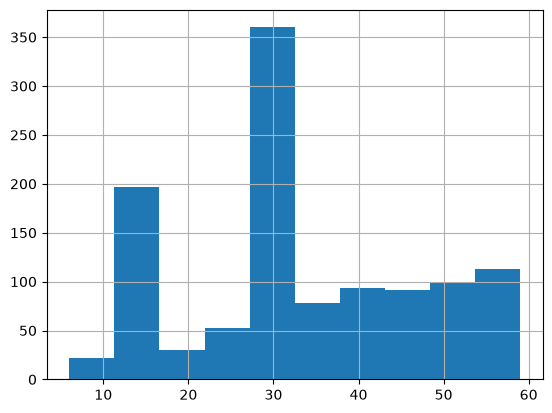

In [73]:
import matplotlib.pyplot as plt
df_model["duration_seconds"].hist()
plt.show()

In [74]:
df_model.head()

video_id   youtube_id  recall_score  \
0        37  3DK8I80Yhgs          0.80   
1      1055  2ZsxgpRMBDg          0.57   
2       761  00STtvbodn8          0.43   
3      2383  lgskk192v8Q          1.00   
4      2084  pdsBuJu7fnQ          1.00   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  audio  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              Two full meals, $5.99 each. Marparoya, crispy two fries, two drinks. Double them up or mix and match. Whatever you want, we're into that. BK, having your way. You rule!   
1                                                                                                                                                                                                                                                                                                          Who doesn't dream about having smooth, silky, touchable hair? Well now, dreams do come true. Smooth, sexy hair with its essential ingredient of coconut oil contain the most unruly of locks. Phase out frizz and embrace your sleek and sexy side. This complete system of shampoo, conditioner, blow-dry extender and finishing products will keep your moves smooth day after day. Get sexy smooth today.   
2                                                                                                                                                                                                                                                                                                                                                                        When you shop at Burlington, you'll find the latest looks, the hottest styles, the brands you love. At prices so low, you'll want it all. Burlington gives you incredible deals and amazing brands and styles at everyday low prices. It's simple. At Burlington, you get a lot for a lot less. You'll love the deals. You'll love Burlington.   
3                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    It's time that I told you the story of Aladdin the princess and the lamp You stumbled upon an opportunity your life begins now Do you trust me You   
4  You might be interested to know that your vehicle may have a rear view mirror that allows for greater adjustability, so you can position it to your comfort for enhanced visibility. Let me explain. Your vehicle's rear view mirror has two pivot points, o

In [75]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 727 entries, 568 to 1053
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   video_id      727 non-null    int64  
 1   youtube_id    727 non-null    str    
 2   recall_score  727 non-null    float64
 3   audio         727 non-null    str    
 4   audio_clean   727 non-null    str    
dtypes: float64(1), int64(1), str(3)
memory usage: 535.9 KB


In [76]:
# Merge vào train_df, val_df, test_df theo video_id; youtube_id
train_df_d = train_df.merge(df_model[["video_id", "youtube_id", "duration_seconds"]], on=["video_id", "youtube_id"], how="left")
val_df_d   = val_df.merge(df_model[["video_id", "youtube_id", "duration_seconds"]], on=["video_id", "youtube_id"], how="left")
test_df_d  = test_df.merge(df_model[["video_id", "youtube_id", "duration_seconds"]], on=["video_id", "youtube_id"], how="left")

print(train_df_d[["video_id", "youtube_id", "duration_seconds"]].head())

   video_id   youtube_id  duration_seconds
0       819  e-2KY1cUCCA              39.0
1        12  NPGTKfElfkI              15.0
2      2208  kpIonWiYwWc              11.0
3      2349  3AkEwhZdXN4              30.0
4      2001  caIAjaea8Qw              30.0


In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_duration = scaler.fit_transform(train_df_d[["duration_seconds"]])
val_duration   = scaler.transform(val_df_d[["duration_seconds"]])
test_duration  = scaler.transform(test_df_d[["duration_seconds"]])

X_train_distilbert_duration = np.hstack([X_train_distilbert, train_duration])
X_val_distilbert_duration   = np.hstack([X_val_distilbert,   val_duration])
X_test_distilbert_duration  = np.hstack([X_test_distilbert,  test_duration])

print("Shape new:", X_train_distilbert_duration.shape)  # 768 + 1 = 769

Shape new: (727, 769)


In [78]:
distilbert_duration_linear_model = LinearRegression()

distilbert_duration_linear_model.fit(X_train_distilbert_duration, y_train)

val_preds_distilbert_duration_linear = distilbert_duration_linear_model.predict(X_val_distilbert_duration)

distilbert_duration_linear_val_result = evaluate_regression(
    y_true=y_val,
    y_pred=val_preds_distilbert_duration_linear,
    model_name="DistilBERT + Duration + Linear Regression Validation"
)
distilbert_duration_linear_val_result

{'model': 'DistilBERT + Duration + Linear Regression Validation',
 'MAE': 0.9484396253594845,
 'RMSE': np.float64(1.3434249948256507),
 'R2': -20.099230876746812,
 'Pearson': np.float64(0.01993771997250395),
 'Spearman': np.float64(0.06362933827553878)}

In [79]:
test_preds_distilbert_duration_linear = distilbert_duration_linear_model.predict(X_test_distilbert_duration)

distilbert_duration_linear_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds_distilbert_duration_linear,
    model_name="DistilBERT + Duration + Linear Regression Test"
)
distilbert_duration_linear_test_result

{'model': 'DistilBERT + Duration + Linear Regression Test',
 'MAE': 0.9893630966583192,
 'RMSE': np.float64(1.3073860346888044),
 'R2': -18.62414206362048,
 'Pearson': np.float64(0.16188700657754887),
 'Spearman': np.float64(0.1455516778061749)}

In [80]:
distilbert_duration_ridge_model = Ridge(alpha=1.0)

distilbert_duration_ridge_model.fit(X_train_distilbert_duration, y_train)

val_preds_distilbert_duration_ridge = distilbert_duration_ridge_model.predict(X_val_distilbert_duration)

distilbert_duration_ridge_val_result = evaluate_regression(
    y_true=y_val,
    y_pred=val_preds_distilbert_duration_ridge,
    model_name="DistilBERT + Duration + Ridge Regression Validation"
)
distilbert_duration_ridge_val_result

{'model': 'DistilBERT + Duration + Ridge Regression Validation',
 'MAE': 0.2858252844591691,
 'RMSE': np.float64(0.34222629701607177),
 'R2': -0.3691988704700149,
 'Pearson': np.float64(0.009444403840754581),
 'Spearman': np.float64(-0.019693961764171913)}

In [81]:
distilbert_duration_results = []

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200]:
    model = Ridge(alpha=alpha)
    model.fit(X_train_distilbert_duration, y_train)
    
    val_preds = model.predict(X_val_distilbert_duration)
    
    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"DistilBERT + Duration + Ridge Validation alpha={alpha}"
    )
    
    result["alpha"] = alpha
    distilbert_duration_results.append(result)

distilbert_duration_results_df = pd.DataFrame(distilbert_duration_results)
distilbert_duration_results_df.sort_values("RMSE", ascending=True)

,model,MAE,RMSE,R2,Pearson,Spearman,alpha
4,DistilBERT + Duration + Ridge Validation alpha=100.0,0.235081,0.277907,0.097100,0.323300,0.331319,100.0
3,DistilBERT + Duration + Ridge Validation alpha=50.0,0.234344,0.278198,0.095211,0.310766,0.317908,50.0
5,DistilBERT + Duration + Ridge Validation alpha=200,0.236934,0.279347,0.087723,0.318553,0.327096,200.0
2,DistilBERT + Duration + Ridge Validation alpha=10.0,0.244104,0.290872,0.010893,0.204058,0.188944,10.0
1,DistilBERT + Duration + Ridge Validation alpha=1.0,0.285825,0.342226,-0.369199,0.009444,-0.019694,1.0
0,DistilBERT + Duration + Ridge Validation alpha=0.1,0.364362,0.458878,-1.461694,-0.038688,-0.054317,0.1


In [82]:
best_model = Ridge(alpha=100)
best_model.fit(X_train_distilbert_duration, y_train)

test_preds = best_model.predict(X_test_distilbert_duration)

distilbert_duration_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds,
    model_name=f"DistilBERT + Duration + Ridge Test alpha={100}"
)

distilbert_duration_test_result

{'model': 'DistilBERT + Duration + Ridge Test alpha=100',
 'MAE': 0.23264095057342357,
 'RMSE': np.float64(0.2753635884341738),
 'R2': 0.12944538697592411,
 'Pearson': np.float64(0.37860424665566944),
 'Spearman': np.float64(0.377913740290729)}

In [83]:
#besser R2+0.1 als disstilbert allein

In [84]:
df_model["Brand"].describe()

count        1137
unique        232
top       Netflix
freq           78
Name: Brand, dtype: object

In [85]:
print(df_model["Brand"].value_counts(dropna=False))

Brand
Netflix                       78
Walt-Disney                   72
Ulta Beauty                   41
Costco                        30
Amazon                        24
                              ..
Williams                       1
The Coffee Bean & Tea Leaf     1
American Family Insurance      1
Stanley Black&Decker           1
Dollar General                 1
Name: count, Length: 232, dtype: int64


In [86]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge

train_df_b = train_df.merge(df_model[["video_id", "youtube_id", "Brand"]], on=["video_id", "youtube_id"], how="left")
val_df_b   = val_df.merge(df_model[["video_id", "youtube_id", "Brand"]], on=["video_id", "youtube_id"], how="left")
test_df_b  = test_df.merge(df_model[["video_id", "youtube_id", "Brand"]], on=["video_id", "youtube_id"], how="left")

brand_counts = train_df_b["Brand"].value_counts()
top_brands = brand_counts[brand_counts >= 10].index

def group_minority_brands(brand_name):
    return brand_name if brand_name in top_brands else "Others"

# Áp dụng hàm gom nhóm lên cả 3 tập
train_df_b["brand_grouped"] = train_df_b["Brand"].apply(group_minority_brands)
val_df_b["brand_grouped"]   = val_df_b["Brand"].apply(group_minority_brands)
test_df_b["brand_grouped"]  = test_df_b["Brand"].apply(group_minority_brands)

print("Brand list:", train_df_b["brand_grouped"].nunique())

# drop='first' để loại bỏ 1 cột ảo nhằm tránh hiện tượng đa cộng tuyến hoàn hảo
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

# Fit trên tập train và transform cho cả 3 tập
train_brand_ohe = ohe.fit_transform(train_df_b[["brand_grouped"]])
val_brand_ohe   = ohe.transform(val_df_b[["brand_grouped"]])
test_brand_ohe  = test_brand_ohe = ohe.transform(test_df_b[["brand_grouped"]])


X_train_brand_ohe = np.hstack([X_train_distilbert, train_brand_ohe])
X_val_brand_ohe   = np.hstack([X_val_distilbert,   val_brand_ohe])
X_test_brand_ohe  = np.hstack([X_test_distilbert,  test_brand_ohe])

print("Shape new Brand:", X_train_distilbert.shape) 

distilbert_brand_results = []
for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200, 500]:
    model = Ridge(alpha=alpha)
    model.fit(X_train_brand_ohe, y_train)
    
    val_preds = model.predict(X_val_brand_ohe)
    
    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"DistilBERT Brand + Ridge Validation alpha={alpha}"
    )
    
    result["alpha"] = alpha
    distilbert_brand_results.append(result)

distilbert_brand_results_df = pd.DataFrame(distilbert_brand_results)
distilbert_brand_results_df.sort_values("RMSE", ascending=True)

Brand list: 13
Shape new Brand: (727, 768)


,model,MAE,RMSE,R2,Pearson,Spearman,alpha
3,DistilBERT Brand + Ridge Validation alpha=50.0,0.225713,0.269684,0.149745,0.392606,0.380947,50.0
4,DistilBERT Brand + Ridge Validation alpha=100.0,0.226799,0.270105,0.147087,0.402753,0.400905,100.0
5,DistilBERT Brand + Ridge Validation alpha=200,0.229487,0.272639,0.131008,0.398309,0.394664,200.0
6,DistilBERT Brand + Ridge Validation alpha=500,0.234545,0.277681,0.098568,0.377648,0.375019,500.0
2,DistilBERT Brand + Ridge Validation alpha=10.0,0.234997,0.281150,0.075906,0.306091,0.289558,10.0
1,DistilBERT Brand + Ridge Validation alpha=1.0,0.275185,0.331304,-0.283193,0.112878,0.094016,1.0
0,DistilBERT Brand + Ridge Validation alpha=0.1,0.341559,0.440141,-1.264765,0.027220,0.017909,0.1


In [87]:
print( "brand:", df_model["Brand"].nunique())
print(df_model["Brand"].value_counts().head(10))

# Kiểm tra brand có bị lặp giữa train và test không
train_brands = set(train_df_b["Brand"].unique())
test_brands = set(test_df_b["Brand"].unique())
print("Brand overlap train/test:", len(train_brands & test_brands))
print("prozentuelle overlap:", len(train_brands & test_brands) / len(test_brands))

brand: 232
Brand
Netflix                  78
Walt-Disney              72
Ulta Beauty              41
Costco                   30
Amazon                   24
Homedepot                23
Adobe                    22
Dick'S Sporting Goods    21
Nvidia                   19
Wayfair                  18
Name: count, dtype: int64
Brand overlap train/test: 93
prozentuelle overlap: 0.8303571428571429


In [88]:
#Nếu tỷ lệ overlap cao (ví dụ >70%) và số lượng brand ít so với số mẫu → R²+0.7 nhiều khả năng phản ánh model đang đoán theo brand, không phải theo nội dung audio — cần nêu rõ giới hạn này trong báo cáo, không nên báo cáo như một phát hiện "audio+brand dự đoán tốt".

In [89]:
best_model = Ridge(alpha=50)
best_model.fit(X_train_brand_ohe, y_train)

test_preds = best_model.predict(X_test_brand_ohe)

distilbert_brand_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds,
    model_name=f"DistilBERT + Brand + Ridge Test alpha={50}"
)

distilbert_brand_test_result

{'model': 'DistilBERT + Brand + Ridge Test alpha=50',
 'MAE': 0.22465496762515694,
 'RMSE': np.float64(0.26617221525842083),
 'R2': 0.18659200984057533,
 'Pearson': np.float64(0.4485898783561057),
 'Spearman': np.float64(0.4450428319054551)}

In [90]:
#R2 +7% besser

In [91]:
brand_feature_names = ohe.get_feature_names_out(['brand_grouped'])
# List: 768 chiều BERT (đặt tên chung) + các cột Brand
all_feature_names = [f"BERT_dim_{i}" for i in range(768)] + list(brand_feature_names)

coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": best_model.coef_
})

brand_coef_df = coef_df[coef_df["Feature"].str.contains("brand_grouped")].copy()

brand_coef_df = brand_coef_df.sort_values(by="Coefficient", ascending=False)
print(brand_coef_df)

                                 Feature  Coefficient
775                brand_grouped_Netflix     0.057087
773     brand_grouped_Ford Motor Company     0.031666
776                 brand_grouped_Nvidia     0.025411
770          brand_grouped_Cisco Systems     0.020981
768                 brand_grouped_Amazon     0.014882
779            brand_grouped_Walt-Disney     0.010097
772  brand_grouped_Dick'S Sporting Goods     0.008888
778            brand_grouped_Ulta Beauty    -0.002945
771                 brand_grouped_Costco    -0.023599
774              brand_grouped_Homedepot    -0.025057
769                   brand_grouped_At&T    -0.039937
777                 brand_grouped_Others    -0.095703


In [92]:
#hương hiệu Nike có hệ số tác động là +0.0570. Điều này có nghĩa là trong cùng một điều kiện về nội dung kịch bản (Audio) và thời lượng video, một video được phát hành bởi thương hiệu Nike sẽ giúp điểm số Recall Score trung bình tăng thêm 0.0850 (tương đương tăng 8.5%) so với khi video đó được phát hành bởi các thương hiệu nhỏ lẻ trong nhóm Others."

In [93]:
df_model["Orientation"].describe()

count          1137
unique            3
top       landscape
freq           1107
Name: Orientation, dtype: object

In [94]:

train_df_o = train_df.merge(df_model[["video_id", "youtube_id", "Orientation"]], on=["video_id", "youtube_id"], how="left")
val_df_o   = val_df.merge(df_model[["video_id", "youtube_id", "Orientation"]], on=["video_id", "youtube_id"], how="left")
test_df_o  = test_df.merge(df_model[["video_id", "youtube_id", "Orientation"]], on=["video_id", "youtube_id"], how="left")


print("Orientation:", train_df_o["Orientation"].unique())

ohe_ori = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

train_ori_ohe = ohe_ori.fit_transform(train_df_o[["Orientation"]])
val_ori_ohe   = ohe_ori.transform(val_df_o[["Orientation"]])
test_ori_ohe  = ohe_ori.transform(test_df_o[["Orientation"]])

X_train_ori_ohe = np.hstack([X_train_distilbert, train_ori_ohe])
X_val_ori_ohe   = np.hstack([X_val_distilbert,   val_ori_ohe])
X_test_ori_ohe  = np.hstack([X_test_distilbert,  test_ori_ohe])

print("Shape Audio + Orientation):", X_train_ori_ohe.shape)

distilbert_orientation_results = []

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200, 500]:
    model = Ridge(alpha=alpha)
    model.fit(X_train_ori_ohe, y_train)
    
    val_preds = model.predict(X_val_ori_ohe)
    
    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"DistilBERT Orientation + Ridge Validation alpha={alpha}"
    )
    
    result["alpha"] = alpha
    distilbert_orientation_results.append(result)


distilbert_orientation_results_df = pd.DataFrame(distilbert_orientation_results)
distilbert_orientation_results_df.sort_values("RMSE", ascending=True)

Orientation: <ArrowStringArray>
['landscape', 'square', 'portrait']
Length: 3, dtype: str
Shape Audio + Orientation): (727, 770)


,model,MAE,RMSE,R2,Pearson,Spearman,alpha
4,DistilBERT Orientation + Ridge Validation alpha=100.0,0.233896,0.276736,0.104692,0.341060,0.349910,100.0
3,DistilBERT Orientation + Ridge Validation alpha=50.0,0.233360,0.276967,0.103199,0.325854,0.323587,50.0
5,DistilBERT Orientation + Ridge Validation alpha=200,0.235821,0.278388,0.093972,0.336972,0.346006,200.0
6,DistilBERT Orientation + Ridge Validation alpha=500,0.239109,0.281797,0.071650,0.316568,0.322384,500.0
2,DistilBERT Orientation + Ridge Validation alpha=10.0,0.242793,0.290316,0.014673,0.209489,0.201934,10.0
1,DistilBERT Orientation + Ridge Validation alpha=1.0,0.285293,0.342736,-0.373284,0.006317,-0.018183,1.0
0,DistilBERT Orientation + Ridge Validation alpha=0.1,0.362697,0.456620,-1.437527,-0.038216,-0.054976,0.1


In [95]:
best_model = Ridge(alpha=100)
best_model.fit(X_train_ori_ohe, y_train)

test_preds = best_model.predict(X_test_ori_ohe)

distilbert_orientation_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds,
    model_name=f"DistilBERT + Orientation + Ridge Test alpha={100}"
)

distilbert_orientation_test_result

{'model': 'DistilBERT + Orientation + Ridge Test alpha=100',
 'MAE': 0.23274737393890677,
 'RMSE': np.float64(0.2754406753230057),
 'R2': 0.12895790248017858,
 'Pearson': np.float64(0.3789088791816818),
 'Spearman': np.float64(0.3841031605333451)}

In [96]:
#R2 bleibt gleich

In [97]:
print(df_model["Pace"].value_counts(dropna=False))

Pace
low       716
medium    380
high       41
Name: count, dtype: int64


In [98]:
df_model["Pace"].info()

<class 'pandas.Series'>
RangeIndex: 1137 entries, 0 to 1136
Series name: Pace
Non-Null Count  Dtype
--------------  -----
1137 non-null   str  
dtypes: str(1)
memory usage: 13.6 KB


In [99]:
train_df_p = train_df.merge(df_model[["video_id", "youtube_id", "Pace"]], on=["video_id", "youtube_id"], how="left")
val_df_p   = val_df.merge(df_model[["video_id", "youtube_id", "Pace"]], on=["video_id", "youtube_id"], how="left")
test_df_p  = test_df.merge(df_model[["video_id", "youtube_id", "Pace"]], on=["video_id", "youtube_id"], how="left")

print("Pace:", train_df_p["Pace"].unique())

ohe_pace = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

train_pace_ohe = ohe_pace.fit_transform(train_df_p[["Pace"]])
val_pace_ohe   = ohe_pace.transform(val_df_p[["Pace"]])
test_pace_ohe  = ohe_pace.transform(test_df_p[["Pace"]])

X_train_pace_ohe = np.hstack([X_train_distilbert, train_pace_ohe])
X_val_pace_ohe   = np.hstack([X_val_distilbert,   val_pace_ohe])
X_test_pace_ohe  = np.hstack([X_test_distilbert,  test_pace_ohe])

print("Shape (Audio + Pace):", X_train_pace_ohe.shape)


distilbert_pace_results = []

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200, 500]:
    model = Ridge(alpha=alpha)
    model.fit(X_train_pace_ohe, y_train)

    val_preds = model.predict(X_val_pace_ohe)
    
    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"DistilBERT Pace + Ridge Validation alpha={alpha}"
    )
    
    result["alpha"] = alpha
    distilbert_pace_results.append(result)

distilbert_pace_results_df = pd.DataFrame(distilbert_pace_results)
distilbert_pace_results_df.sort_values("RMSE", ascending=True)

Pace: <ArrowStringArray>
['medium', 'high', 'low']
Length: 3, dtype: str
Shape (Audio + Pace): (727, 770)


,model,MAE,RMSE,R2,Pearson,Spearman,alpha
4,DistilBERT Pace + Ridge Validation alpha=100.0,0.233131,0.275510,0.112608,0.353610,0.360353,100.0
3,DistilBERT Pace + Ridge Validation alpha=50.0,0.232579,0.275777,0.110888,0.337816,0.342787,50.0
5,DistilBERT Pace + Ridge Validation alpha=200,0.235045,0.277190,0.101755,0.350829,0.357759,200.0
6,DistilBERT Pace + Ridge Validation alpha=500,0.238333,0.280793,0.078252,0.331780,0.340091,500.0
2,DistilBERT Pace + Ridge Validation alpha=10.0,0.241598,0.289038,0.023327,0.225203,0.222673,10.0
1,DistilBERT Pace + Ridge Validation alpha=1.0,0.283236,0.341235,-0.361278,0.021879,0.007166,1.0
0,DistilBERT Pace + Ridge Validation alpha=0.1,0.363129,0.456202,-1.433070,-0.035451,-0.050071,0.1


In [100]:
best_model = Ridge(alpha=100)
best_model.fit(X_train_pace_ohe, y_train)

test_preds = best_model.predict(X_test_pace_ohe)

distilbert_pace_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds,
    model_name=f"DistilBERT + Pace + Ridge Test alpha={100}"
)

distilbert_pace_test_result

{'model': 'DistilBERT + Pace + Ridge Test alpha=100',
 'MAE': 0.2335536951081771,
 'RMSE': np.float64(0.27637174915859153),
 'R2': 0.12305917145548739,
 'Pearson': np.float64(0.366166486582973),
 'Spearman': np.float64(0.36985249141568355)}

In [101]:
#R2 ein bisschen schlechter als R2 Distilbert

In [102]:
print(df_model["Scenes"].iloc[0])

[{'Colors': 'Dark_Brown,Red,Mustard,Gold,Beige,Orange,Red,Cream,Beige', 'Description': 'shows a retro burger king poster on an array of colored background', 'Emotions': 'fancy, delicious', 'Number': '1', 'Photography Style': '', 'Tags': 'art, brand, illustration, logo, poster, sock', 'Text Shown': "KING'", 'Tone': 'warm', 'Visual Complexity': 'Low'}
 {'Colors': 'Cream,Orange,Dark_Brown,Brown,Orange,Tan', 'Description': 'shows a king crab sandwich and a burger are shown on a tray', 'Emotions': 'dish, tasty', 'Number': '2', 'Photography Style': 'commercial', 'Tags': 'advertisement, beverage, coke, drink, food, fry, hamburger, soda, tray', 'Text Shown': '2\', \'meals$\', \'for\', \'each\', \'When you buy2 meals only\', \'Sprite\', \'BURGER\', \'KING\', \'BURGER\', \'KING\', \'"BK\'Royal Crispy"\', \'WhopperMeal\', \'OR\', \'Chicken Meal\'', 'Tone': 'neutral', 'Visual Complexity': ''}
 {'Colors': 'Dark_Brown,Dark_Brown,Brown,Maroon,Mud_Green', 'Description': 'shows a picture of a chicken b

In [103]:
import ast
from collections import Counter

# Parse Scenes nếu đang ở dạng string
df_model["Scenes"] = df_model["Scenes"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

def aggregate_colors(scenes):
    colors = set()
    for scene in scenes:
        val = scene.get("Colors", "")
        if isinstance(val, str) and val.strip():
            for c in val.split(","):
                colors.add(c.strip())
    return ", ".join(sorted(colors))

df_model["scenes_colors"] = df_model["Scenes"].apply(aggregate_colors)

df_model[["video_id", "scenes_colors"]].head()

,video_id,scenes_colors
0,37,"Beige, Black, Brown, Cream, Dark_Brown, Dark_Red, Gold, Khaki, Maroon, Mud_Green, Mustard, Olive, Orange, Pink, Red, Tan"
1,1055,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray, Dark_Pink, Dark_Red, Gray, Maroon, Off_White, Pink, Purple, Red, Violet, White"
2,761,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray, Dark_Green, Dark_Pink, Dark_Red, Emerald, Gray, Khaki, Lavender, Light_Blue, Maroon, Off_White, Olive, Orange, Pink, Plum, Red, Royal_Blue, Silver, White"
3,2383,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray, Dark_Pink, Dark_Red, Gray, Khaki, Lilac, Magenta, Maroon, Mud_Green, Off_White, Pink, Purple, Royal_Blue, Tan"
4,2084,"Black, Dark_Blue, Dark_Gray, Gray, Lavender, Light_Blue, Royal_Blue, White"


In [104]:
import numpy as np

color_counts = Counter()
df_model["scenes_colors"].dropna().apply(
    lambda x: color_counts.update([c.strip() for c in x.split(",") if c.strip()])
)
top_colors = [color for color, count in color_counts.most_common(15)]
print("Top 15 color:", top_colors)

def encode_colors(df, color_col="scenes_colors"):
    return np.array([
        [int(c in [x.strip() for x in str(row).split(",")]) for c in top_colors]
        for row in df[color_col].fillna("")
    ])

Top 15 color: ['Black', 'Dark_Brown', 'Gray', 'Dark_Gray', 'White', 'Brown', 'Dark_Blue', 'Mud_Green', 'Olive', 'Off_White', 'Orange', 'Khaki', 'Light_Blue', 'Dark_Pink', 'Dark_Green']


In [105]:
df_model["scenes_colors"].head()

0                                                                                     Beige, Black, Brown, Cream, Dark_Brown, Dark_Red, Gold, Khaki, Maroon, Mud_Green, Mustard, Olive, Orange, Pink, Red, Tan
1                                                                               Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray, Dark_Pink, Dark_Red, Gray, Maroon, Off_White, Pink, Purple, Red, Violet, White
2    Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray, Dark_Green, Dark_Pink, Dark_Red, Emerald, Gray, Khaki, Lavender, Light_Blue, Maroon, Off_White, Olive, Orange, Pink, Plum, Red, Royal_Blue, Silver, White
3                                                Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray, Dark_Pink, Dark_Red, Gray, Khaki, Lilac, Magenta, Maroon, Mud_Green, Off_White, Pink, Purple, Royal_Blue, Tan
4                                                                                                                                   Black, Dark_Blue, Dark_Gray, Gray, Laven

In [106]:
train_df_c = train_df.merge(df_model[["video_id", "youtube_id", "scenes_colors"]], on=["video_id", "youtube_id"], how="left")
val_df_c   = val_df.merge(df_model[["video_id", "youtube_id", "scenes_colors"]], on=["video_id", "youtube_id"], how="left")
test_df_c  = test_df.merge(df_model[["video_id", "youtube_id","scenes_colors"]], on=["video_id", "youtube_id"], how="left")

train_color = encode_colors(train_df_c)
val_color   = encode_colors(val_df_c)
test_color  = encode_colors(test_df_c)

print("Color feature shape:", train_color.shape)  # (n_samples, 15)

Color feature shape: (727, 15)


In [107]:
X_train_distilbert_color = np.hstack([X_train_distilbert, train_color])
X_val_distilbert_color   = np.hstack([X_val_distilbert,   val_color])
X_test_distilbert_color  = np.hstack([X_test_distilbert,  test_color])

print("Shape neu:", X_train_distilbert_color.shape)  # 768 + 15 = 783

Shape neu: (727, 783)


In [108]:
distilbert_color_results = []

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200]:
    model = Ridge(alpha=alpha)
    model.fit(X_train_distilbert_color, y_train)
    val_preds = model.predict(X_val_distilbert_color)
    
    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"DistilBERT + Color + Ridge Validation alpha={alpha}"
    )
    result["alpha"] = alpha
    distilbert_color_results.append(result)

distilbert_color_results_df = pd.DataFrame(distilbert_color_results)
distilbert_color_results_df.sort_values("RMSE", ascending=True)

,model,MAE,RMSE,R2,Pearson,Spearman,alpha
4,DistilBERT + Color + Ridge Validation alpha=100.0,0.233494,0.276278,0.107655,0.343244,0.352738,100.0
3,DistilBERT + Color + Ridge Validation alpha=50.0,0.232177,0.276390,0.106931,0.330270,0.334246,50.0
5,DistilBERT + Color + Ridge Validation alpha=200,0.235833,0.277999,0.096503,0.338920,0.341795,200.0
2,DistilBERT + Color + Ridge Validation alpha=10.0,0.241538,0.289255,0.021858,0.226974,0.220573,10.0
1,DistilBERT + Color + Ridge Validation alpha=1.0,0.283342,0.341683,-0.364852,0.031404,0.014486,1.0
0,DistilBERT + Color + Ridge Validation alpha=0.1,0.362931,0.457692,-1.448983,-0.013113,-0.036181,0.1


In [109]:
best_model = Ridge(alpha=100)
best_model.fit(X_train_distilbert_color, y_train)

test_preds = best_model.predict(X_test_distilbert_color)

distilbert_color_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds,
    model_name=f"DistilBERT + Color + Ridge Test alpha={100}"
)

distilbert_color_test_result

{'model': 'DistilBERT + Color + Ridge Test alpha=100',
 'MAE': 0.23028026853016853,
 'RMSE': np.float64(0.27280024876956377),
 'R2': 0.14557780753414806,
 'Pearson': np.float64(0.40653576629656),
 'Spearman': np.float64(0.41083643166131817)}

In [110]:
#R2 +2% besser

In [111]:
def aggregate_emotions(scenes):
    emotions = set()
    for scene in scenes:
        val = scene.get("Emotions", "")
        if isinstance(val, str) and val.strip():
            for e in val.split(","):
                e_clean = e.strip().lower()
                if e_clean:
                    emotions.add(e_clean)
    return ", ".join(sorted(emotions))

df_model["scenes_emotions"] = df_model["Scenes"].apply(aggregate_emotions)

df_model[["video_id", "scenes_emotions"]].head()

,video_id,scenes_emotions
0,37,"bitter, confidence, confident, delicious, dish, fancy, funky, gift, junk, positive, tasty, toast"
1,1055,"bad, care, comfort, comfortable, disgust, disgusting, erotic, fetish, happy, laugh, love, perfect, positive, relaxation, romance, scream, smile, smiling, touching, unpleasant"
2,761,"attentive, casual, fancy, fantasy, friendly, gift, happy, holiday, intimate, joyous, love, playful, relaxed, romance, satisfied, sincere, smiley, valentine, wedding, wish"
3,2383,"adventure, adversity, amusing, celebration, cheering, eer, fantasy, fear, gift, good, halloween, holiday, horror, lonely, luck, lucky, magical, mysterious, romance, romantic, solitary"
4,2084,"accident, amazement, dangerous, emergency"


In [112]:
from collections import Counter
import numpy as np

emotion_counts = Counter()
df_model["scenes_emotions"].dropna().apply(
    lambda x: emotion_counts.update([e.strip() for e in x.split(",") if e.strip()])
)
top_emotions = [e for e, c in emotion_counts.most_common(15)]
print("Top 15 emotions:", top_emotions)

def encode_emotions(df, emotion_col="scenes_emotions"):
    return np.array([
        [int(e in [x.strip() for x in str(row).split(",")]) for e in top_emotions]
        for row in df[emotion_col].fillna("")
    ])

Top 15 emotions: ['happy', 'gift', 'good', 'smiling', 'emergency', 'togetherness', 'casual', 'achievement', 'smile', 'holiday', 'danger', 'cheerful', 'bad', 'fun', 'problem']


In [113]:
train_df_e = train_df.merge(df_model[["video_id", "youtube_id", "scenes_emotions"]], on=["video_id", "youtube_id"], how="left")
val_df_e   = val_df.merge(df_model[["video_id", "youtube_id", "scenes_emotions"]], on=["video_id", "youtube_id"], how="left")
test_df_e  = test_df.merge(df_model[["video_id", "youtube_id", "scenes_emotions"]], on=["video_id", "youtube_id"], how="left")

train_emotion = encode_emotions(train_df_e)
val_emotion   = encode_emotions(val_df_e)
test_emotion  = encode_emotions(test_df_e)

print("Emotion feature shape:", train_emotion.shape)  # (n_samples, 15)

Emotion feature shape: (727, 15)


In [114]:
X_train_distilbert_emotion = np.hstack([X_train_distilbert, train_emotion])
X_val_distilbert_emotion   = np.hstack([X_val_distilbert,   val_emotion])
X_test_distilbert_emotion  = np.hstack([X_test_distilbert,  test_emotion])

print("Shape neu:", X_train_distilbert_emotion.shape)  # 768 + 15 = 783

Shape neu: (727, 783)


In [115]:
distilbert_emotion_results = []

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200]:
    model = Ridge(alpha=alpha)
    model.fit(X_train_distilbert_emotion, y_train)
    val_preds = model.predict(X_val_distilbert_emotion)
    
    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"DistilBERT + Emotion + Ridge Validation alpha={alpha}"
    )
    result["alpha"] = alpha
    distilbert_emotion_results.append(result)

distilbert_emotion_results_df = pd.DataFrame(distilbert_emotion_results)
distilbert_emotion_results_df.sort_values("RMSE", ascending=True)

,model,MAE,RMSE,R2,Pearson,Spearman,alpha
4,DistilBERT + Emotion + Ridge Validation alpha=100.0,0.229973,0.272930,0.129155,0.388096,0.392332,100.0
3,DistilBERT + Emotion + Ridge Validation alpha=50.0,0.229424,0.272982,0.128820,0.369018,0.369520,50.0
5,DistilBERT + Emotion + Ridge Validation alpha=200,0.232247,0.275172,0.114787,0.383879,0.392001,200.0
2,DistilBERT + Emotion + Ridge Validation alpha=10.0,0.238937,0.287406,0.034326,0.245642,0.241928,10.0
1,DistilBERT + Emotion + Ridge Validation alpha=1.0,0.284816,0.343127,-0.376413,0.040024,0.031797,1.0
0,DistilBERT + Emotion + Ridge Validation alpha=0.1,0.357635,0.456067,-1.431626,-0.033125,-0.037092,0.1


In [116]:
best_model = Ridge(alpha=100)
best_model.fit(X_train_distilbert_emotion, y_train)

test_preds = best_model.predict(X_test_distilbert_emotion)

distilbert_emotion_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds,
    model_name=f"DistilBERT + emotion + Ridge Test alpha={100}"
)

distilbert_emotion_test_result

{'model': 'DistilBERT + emotion + Ridge Test alpha=100',
 'MAE': 0.23102644144214018,
 'RMSE': np.float64(0.2743096793677661),
 'R2': 0.1360964452518184,
 'Pearson': np.float64(0.3841849438571267),
 'Spearman': np.float64(0.38732792090732665)}

In [117]:
#r2 +0.1 besser

In [118]:
merge_cols = ["video_id", "youtube_id", "duration_seconds", "scenes_colors", "scenes_emotions"]

train_df_f = train_df.merge(df_model[merge_cols], on=["video_id", "youtube_id"], how="left")
val_df_f   = val_df.merge(df_model[merge_cols], on=["video_id", "youtube_id"], how="left")
test_df_f  = test_df.merge(df_model[merge_cols], on=["video_id", "youtube_id"], how="left")


In [119]:
import ast
from collections import Counter
import numpy as np

# Parse Scenes nếu đang ở dạng string
df_model["Scenes"] = df_model["Scenes"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

def aggregate_colors(scenes):
    colors = set()
    for scene in scenes:
        val = scene.get("Colors", "")
        if isinstance(val, str) and val.strip():
            for c in val.split(","):
                colors.add(c.strip())
    return ", ".join(sorted(colors))

def aggregate_emotions(scenes):
    emotions = set()
    for scene in scenes:
        val = scene.get("Emotions", "")
        if isinstance(val, str) and val.strip():
            for e in val.split(","):
                e_clean = e.strip().lower()
                if e_clean:
                    emotions.add(e_clean)
    return ", ".join(sorted(emotions))

df_model["scenes_colors"] = df_model["Scenes"].apply(aggregate_colors)
df_model["scenes_emotions"] = df_model["Scenes"].apply(aggregate_emotions)

df_model[["video_id", "duration_seconds", "scenes_colors", "scenes_emotions"]].head()

,video_id,duration_seconds,scenes_colors,scenes_emotions
0,37,15.0,"Beige, Black, Brown, Cream, Dark_Brown, Dark_Red, Gold, Khaki, Maroon, Mud_Green, Mustard, Olive, Orange, Pink, Red, Tan","bitter, confidence, confident, delicious, dish, fancy, funky, gift, junk, positive, tasty, toast"
1,1055,39.0,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray, Dark_Pink, Dark_Red, Gray, Maroon, Off_White, Pink, Purple, Red, Violet, White","bad, care, comfort, comfortable, disgust, disgusting, erotic, fetish, happy, laugh, love, perfect, positive, relaxation, romance, scream, smile, smiling, touching, unpleasant"
2,761,30.0,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray, Dark_Green, Dark_Pink, Dark_Red, Emerald, Gray, Khaki, Lavender, Light_Blue, Maroon, Off_White, Olive, Orange, Pink, Plum, Red, Royal_Blue, Silver, White","attentive, casual, fancy, fantasy, friendly, gift, happy, holiday, intimate, joyous, love, playful, relaxed, romance, satisfied, sincere, smiley, valentine, wedding, wish"
3,2383,30.0,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray, Dark_Pink, Dark_Red, Gray, Khaki, Lilac, Magenta, Maroon, Mud_Green, Off_White, Pink, Purple, Royal_Blue, Tan","adventure, adversity, amusing, celebration, cheering, eer, fantasy, fear, gift, good, halloween, holiday, horror, lonely, luck, lucky, magical, mysterious, romance, romantic, solitary"
4,2084,54.0,"Black, Dark_Blue, Dark_Gray, Gray, Lavender, Light_Blue, Royal_Blue, White","accident, amazement, dangerous, emergency"


In [120]:
color_counts = Counter()
df_model["scenes_colors"].dropna().apply(
    lambda x: color_counts.update([c.strip() for c in x.split(",") if c.strip()])
)
top_colors = [c for c, cnt in color_counts.most_common(15)]

emotion_counts = Counter()
df_model["scenes_emotions"].dropna().apply(
    lambda x: emotion_counts.update([e.strip() for e in x.split(",") if e.strip()])
)
top_emotions = [e for e, cnt in emotion_counts.most_common(15)]

print("Top colors:", top_colors)
print("Top emotions:", top_emotions)

def encode_multilabel(df, col, top_values):
    return np.array([
        [int(v in [x.strip() for x in str(row).split(",")]) for v in top_values]
        for row in df[col].fillna("")
    ])

Top colors: ['Black', 'Dark_Brown', 'Gray', 'Dark_Gray', 'White', 'Brown', 'Dark_Blue', 'Mud_Green', 'Olive', 'Off_White', 'Orange', 'Khaki', 'Light_Blue', 'Dark_Pink', 'Dark_Green']
Top emotions: ['happy', 'gift', 'good', 'smiling', 'emergency', 'togetherness', 'casual', 'achievement', 'smile', 'holiday', 'danger', 'cheerful', 'bad', 'fun', 'problem']


In [121]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
train_duration = scaler.fit_transform(train_df_f[["duration_seconds"]])
val_duration   = scaler.transform(val_df_f[["duration_seconds"]])
test_duration  = scaler.transform(test_df_f[["duration_seconds"]])


train_color = encode_multilabel(train_df_f, "scenes_colors", top_colors)
val_color   = encode_multilabel(val_df_f,   "scenes_colors", top_colors)
test_color  = encode_multilabel(test_df_f,  "scenes_colors", top_colors)


train_emotion = encode_multilabel(train_df_f, "scenes_emotions", top_emotions)
val_emotion   = encode_multilabel(val_df_f,   "scenes_emotions", top_emotions)
test_emotion  = encode_multilabel(test_df_f,  "scenes_emotions", top_emotions)

In [122]:
X_train_distilbert_combo = np.hstack([X_train_distilbert, train_duration, train_color, train_emotion])
X_val_distilbert_combo   = np.hstack([X_val_distilbert,   val_duration,   val_color,   val_emotion])
X_test_distilbert_combo  = np.hstack([X_test_distilbert,  test_duration,  test_color,  test_emotion])

print("Shape neu:", X_train_distilbert_combo.shape)  # 768 + 1 + 15 + 15 = 799

Shape neu: (727, 799)


In [123]:
distilbert_combo_results = []

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200]:
    model = Ridge(alpha=alpha)
    model.fit(X_train_distilbert_combo, y_train)
    val_preds = model.predict(X_val_distilbert_combo)
    
    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"DistilBERT + Combo Ridge Validation alpha={alpha}"
    )
    result["alpha"] = alpha
    distilbert_combo_results.append(result)

distilbert_combo_results_df = pd.DataFrame(distilbert_combo_results)
distilbert_combo_results_df.sort_values("RMSE", ascending=True)

,model,MAE,RMSE,R2,Pearson,Spearman,alpha
3,DistilBERT + Combo Ridge Validation alpha=50.0,0.229981,0.273954,0.122607,0.354847,0.356049,50.0
4,DistilBERT + Combo Ridge Validation alpha=100.0,0.230865,0.273975,0.122471,0.367585,0.368581,100.0
5,DistilBERT + Combo Ridge Validation alpha=200,0.233565,0.275972,0.109630,0.362976,0.366996,200.0
2,DistilBERT + Combo Ridge Validation alpha=10.0,0.239293,0.286416,0.040964,0.258927,0.255234,10.0
1,DistilBERT + Combo Ridge Validation alpha=1.0,0.281718,0.337516,-0.331768,0.072481,0.052954,1.0
0,DistilBERT + Combo Ridge Validation alpha=0.1,0.348046,0.441795,-1.281823,0.009187,0.001991,0.1


In [124]:
best_model = Ridge(alpha=50)
best_model.fit(X_train_distilbert_combo, y_train)

test_preds = best_model.predict(X_test_distilbert_combo)

distilbert_combo_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds,
    model_name=f"DistilBERT + combo + Ridge Test alpha={5}"
)

distilbert_combo_test_result

{'model': 'DistilBERT + combo + Ridge Test alpha=5',
 'MAE': 0.22509706777118504,
 'RMSE': np.float64(0.26821551553849554),
 'R2': 0.17405564366487147,
 'Pearson': np.float64(0.4277395467927423),
 'Spearman': np.float64(0.4256190044174871)}

In [125]:
# Train lại model với alpha tốt nhất, đặt đúng tên biến để dùng cho phần lấy coefficient
distilbert_combo_ridge_model = Ridge(alpha=50)
distilbert_combo_ridge_model.fit(X_train_distilbert_combo, y_train)

# Kiểm tra R² trên test để chắc chắn khớp với 0.174 bạn đã thấy
test_preds_combo = distilbert_combo_ridge_model.predict(X_test_distilbert_combo)

distilbert_combo_ridge_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds_combo,
    model_name=f"DistilBERT + Duration + Color + Emotion + Ridge Test alpha=50"
)
distilbert_combo_ridge_test_result

{'model': 'DistilBERT + Duration + Color + Emotion + Ridge Test alpha=50',
 'MAE': 0.22509706777118504,
 'RMSE': np.float64(0.26821551553849554),
 'R2': 0.17405564366487147,
 'Pearson': np.float64(0.4277395467927423),
 'Spearman': np.float64(0.4256190044174871)}

In [126]:
coefs = distilbert_combo_ridge_model.coef_

n_embed = X_train_distilbert.shape[1]  # 768
meta_feature_names = ["duration_seconds"] + [f"color_{c}" for c in top_colors] + [f"emotion_{e}" for e in top_emotions]
meta_coefs = coefs[n_embed:]

coef_df = pd.DataFrame({
    "feature": meta_feature_names,
    "coefficient": meta_coefs
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
16,emotion_happy,0.043093
7,color_Dark_Blue,0.024322
25,emotion_holiday,0.024191
0,duration_seconds,0.023272
29,emotion_fun,0.020011
8,color_Mud_Green,0.018751
22,emotion_casual,0.015481
4,color_Dark_Gray,0.013001
12,color_Khaki,0.011564
30,emotion_problem,0.011134


In [127]:
import numpy as np

X_train_distilbert_dur_color = np.hstack([X_train_distilbert, train_duration, train_color])
X_val_distilbert_dur_color   = np.hstack([X_val_distilbert,   val_duration,   val_color])
X_test_distilbert_dur_color  = np.hstack([X_test_distilbert,  test_duration,  test_color])

print("Shape neu:", X_train_distilbert_dur_color.shape)  # 768 + 1 + 15 = 784

Shape neu: (727, 784)


In [128]:
distilbert_dur_color_ridge_model = Ridge(alpha=1.0)
distilbert_dur_color_ridge_model.fit(X_train_distilbert_dur_color, y_train)

val_preds_distilbert_dur_color_ridge = distilbert_dur_color_ridge_model.predict(X_val_distilbert_dur_color)

distilbert_dur_color_ridge_val_result = evaluate_regression(
    y_true=y_val,
    y_pred=val_preds_distilbert_dur_color_ridge,
    model_name="DistilBERT + Duration + Color + Ridge Validation"
)
distilbert_dur_color_ridge_val_result

{'model': 'DistilBERT + Duration + Color + Ridge Validation',
 'MAE': 0.28364226652674457,
 'RMSE': np.float64(0.3404066199395951),
 'R2': -0.35467704120496624,
 'Pearson': np.float64(0.03666672824253838),
 'Spearman': np.float64(0.014618456180525128)}

In [129]:
distilbert_dur_color_results = []

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200]:
    model = Ridge(alpha=alpha)
    model.fit(X_train_distilbert_dur_color, y_train)
    val_preds = model.predict(X_val_distilbert_dur_color)
    
    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"DistilBERT + Duration + Color Ridge Validation alpha={alpha}"
    )
    result["alpha"] = alpha
    distilbert_dur_color_results.append(result)

distilbert_dur_color_results_df = pd.DataFrame(distilbert_dur_color_results)
distilbert_dur_color_results_df.sort_values("RMSE", ascending=True)

,model,MAE,RMSE,R2,Pearson,Spearman,alpha
4,DistilBERT + Duration + Color Ridge Validation alpha=100.0,0.234863,0.277655,0.098740,0.322967,0.328803,100.0
3,DistilBERT + Duration + Color Ridge Validation alpha=50.0,0.233644,0.277803,0.097779,0.313678,0.313379,50.0
5,DistilBERT + Duration + Color Ridge Validation alpha=200,0.237092,0.279112,0.089257,0.317980,0.323958,200.0
2,DistilBERT + Duration + Color Ridge Validation alpha=10.0,0.242885,0.289716,0.018740,0.223058,0.208878,10.0
1,DistilBERT + Duration + Color Ridge Validation alpha=1.0,0.283642,0.340407,-0.354677,0.036667,0.014618,1.0
0,DistilBERT + Duration + Color Ridge Validation alpha=0.1,0.362280,0.456314,-1.434262,-0.007391,-0.032661,0.1


In [130]:
best_alpha_dc = distilbert_dur_color_results_df.sort_values("RMSE", ascending=True).iloc[0]["alpha"]
print("Best alpha:", best_alpha_dc)

best_distilbert_dur_color_ridge_model = Ridge(alpha=best_alpha_dc)
best_distilbert_dur_color_ridge_model.fit(X_train_distilbert_dur_color, y_train)

test_preds_best = best_distilbert_dur_color_ridge_model.predict(X_test_distilbert_dur_color)

distilbert_dur_color_best_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds_best,
    model_name=f"DistilBERT + Duration + Color + Ridge Test alpha={best_alpha_dc}"
)
distilbert_dur_color_best_test_result

Best alpha: 100.0


{'model': 'DistilBERT + Duration + Color + Ridge Test alpha=100.0',
 'MAE': 0.23021002537045052,
 'RMSE': np.float64(0.2726755106312287),
 'R2': 0.14635899939482644,
 'Pearson': np.float64(0.40581145356553006),
 'Spearman': np.float64(0.4049194901873587)}

In [131]:
import pandas as pd


model_to_check = distilbert_dur_color_ridge_model  

coefs = model_to_check.coef_

n_embed = X_train_distilbert.shape[1]  # 768

meta_feature_names = ["duration_seconds"] + [f"color_{c}" for c in top_colors]
meta_coefs = coefs[n_embed:]  # 16 hệ số cuối (1 duration + 15 color)

coef_df = pd.DataFrame({
    "feature": meta_feature_names,
    "coefficient": meta_coefs
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
8,color_Mud_Green,0.055750
12,color_Khaki,0.046960
4,color_Dark_Gray,0.036536
0,duration_seconds,0.027645
7,color_Dark_Blue,0.020566
5,color_White,0.017177
13,color_Light_Blue,0.013301
1,color_Black,0.009712
11,color_Orange,0.007534
2,color_Dark_Brown,0.006158


In [132]:
train_df_po = train_df.merge(
    df_model[["video_id", "youtube_id", "Orientation", "Pace"]],
    on=["video_id", "youtube_id"], how="left"
)
val_df_po = val_df.merge(
    df_model[["video_id", "youtube_id", "Orientation", "Pace"]],
    on=["video_id", "youtube_id"], how="left"
)
test_df_po = test_df.merge(
    df_model[["video_id", "youtube_id", "Orientation", "Pace"]],
    on=["video_id", "youtube_id"], how="left"
)

print("Orientation:", train_df_po["Orientation"].unique())
print("Pace:", train_df_po["Pace"].unique())

Orientation: <ArrowStringArray>
['landscape', 'square', 'portrait']
Length: 3, dtype: str
Pace: <ArrowStringArray>
['medium', 'high', 'low']
Length: 3, dtype: str


In [133]:
from sklearn.preprocessing import OneHotEncoder

ohe_po = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

train_po_ohe = ohe_po.fit_transform(train_df_po[["Orientation", "Pace"]])
val_po_ohe   = ohe_po.transform(val_df_po[["Orientation", "Pace"]])
test_po_ohe  = ohe_po.transform(test_df_po[["Orientation", "Pace"]])

print("Shape OHE (Orientation+Pace):", train_po_ohe.shape)

Shape OHE (Orientation+Pace): (727, 4)


In [134]:
X_train_po_ohe = np.hstack([X_train_distilbert, train_po_ohe])
X_val_po_ohe   = np.hstack([X_val_distilbert,   val_po_ohe])
X_test_po_ohe  = np.hstack([X_test_distilbert,  test_po_ohe])

print("Shape (Audio + Orientation + Pace):", X_train_po_ohe.shape)

Shape (Audio + Orientation + Pace): (727, 772)


In [135]:
distilbert_po_results = []

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200, 500]:
    model = Ridge(alpha=alpha)
    model.fit(X_train_po_ohe, y_train)
    
    val_preds = model.predict(X_val_po_ohe)
    
    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"DistilBERT + Orientation + Pace + Ridge Validation alpha={alpha}"
    )
    
    result["alpha"] = alpha
    distilbert_po_results.append(result)

distilbert_po_results_df = pd.DataFrame(distilbert_po_results)
distilbert_po_results_df.sort_values("RMSE", ascending=True)

,model,MAE,RMSE,R2,Pearson,Spearman,alpha
4,DistilBERT + Orientation + Pace + Ridge Validation alpha=100.0,0.233052,0.275305,0.113928,0.356370,0.363587,100.0
3,DistilBERT + Orientation + Pace + Ridge Validation alpha=50.0,0.232571,0.275435,0.113094,0.341752,0.345395,50.0
5,DistilBERT + Orientation + Pace + Ridge Validation alpha=200,0.235005,0.277081,0.102458,0.352593,0.359301,200.0
6,DistilBERT + Orientation + Pace + Ridge Validation alpha=500,0.238318,0.280751,0.078525,0.332728,0.339384,500.0
2,DistilBERT + Orientation + Pace + Ridge Validation alpha=10.0,0.241526,0.288480,0.027093,0.230213,0.222321,10.0
1,DistilBERT + Orientation + Pace + Ridge Validation alpha=1.0,0.282872,0.340124,-0.352426,0.027940,0.005629,1.0
0,DistilBERT + Orientation + Pace + Ridge Validation alpha=0.1,0.361520,0.452393,-1.392612,-0.028152,-0.047557,0.1


In [136]:
best_alpha_po = 100

best_model = Ridge(alpha=best_alpha_po)
best_model.fit(X_train_po_ohe, y_train)

test_preds = best_model.predict(X_test_po_ohe)

distilbert_orientation_pace_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds,
    model_name=f"DistilBERT + Orientation + Pace + Ridge Test alpha={best_alpha_po}"
)
distilbert_orientation_pace_test_result

{'model': 'DistilBERT + Orientation + Pace + Ridge Test alpha=100',
 'MAE': 0.2333740671876148,
 'RMSE': np.float64(0.2762283890178944),
 'R2': 0.12396871271285781,
 'Pearson': np.float64(0.36790585756832167),
 'Spearman': np.float64(0.3724041813738029)}

In [138]:
df_model["scenes_colors"]

0                                                                                        Beige, Black, Brown, Cream, Dark_Brown, Dark_Red, Gold, Khaki, Maroon, Mud_Green, Mustard, Olive, Orange, Pink, Red, Tan
1                                                                                  Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray, Dark_Pink, Dark_Red, Gray, Maroon, Off_White, Pink, Purple, Red, Violet, White
2       Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray, Dark_Green, Dark_Pink, Dark_Red, Emerald, Gray, Khaki, Lavender, Light_Blue, Maroon, Off_White, Olive, Orange, Pink, Plum, Red, Royal_Blue, Silver, White
3                                                   Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray, Dark_Pink, Dark_Red, Gray, Khaki, Lilac, Magenta, Maroon, Mud_Green, Off_White, Pink, Purple, Royal_Blue, Tan
4                                                                                                                                      Black, Dark_Blue, Dark_Gr

In [146]:
import pandas as pd

# all colors from scenes_colors getrennt
all_colors = (
    df_model["scenes_colors"]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
)
all_colors = all_colors[all_colors != ""]
# colors frequency
color_counts = (
    all_colors
    .value_counts()
    .reset_index()
)

color_counts.columns = ["Color", "Count"]


print(color_counts)


pd.set_option("display.max_rows", None)
display(color_counts)

           Color  Count
0          Black   1006
1     Dark_Brown    953
2           Gray    928
3      Dark_Gray    869
4          White    789
5          Brown    761
6      Dark_Blue    689
7      Mud_Green    638
8          Olive    590
9      Off_White    573
10        Orange    529
11         Khaki    510
12    Light_Blue    492
13     Dark_Pink    480
14    Dark_Green    458
15        Silver    447
16    Royal_Blue    445
17      Dark_Red    398
18          Cyan    376
19          Pink    364
20           Red    359
21       Emerald    358
22      Lavender    288
23        Maroon    254
24         Cream    253
25        Purple    208
26           Tan    200
27          Blue    142
28   Light_Green    138
29       Mustard    118
30     Turquoise    109
31         Beige     95
32          Plum     90
33         Green     90
34        Yellow     90
35         Lilac     84
36          Gold     48
37  Bright_Green     44
38       Magenta     42
39        Violet     40


,Color,Count
0,Black,1006
1,Dark_Brown,953
2,Gray,928
3,Dark_Gray,869
4,White,789
5,Brown,761
6,Dark_Blue,689
7,Mud_Green,638
8,Olive,590
9,Off_White,573


In [153]:
color_groups = {
    "warm": [
        "Red", "Dark_Red", "Maroon", "Orange", "Yellow", "Mustard",
        "Pink", "Dark_Pink", "Magenta", "Brown", "Dark_Brown",
        "Cream", "Beige", "Khaki", "Tan", "Gold"
    ],
    "cool": [
        "Blue", "Dark_Blue", "Royal_Blue", "Light_Blue",
        "Green", "Dark_Green", "Light_Green", "Bright_Green", "Mud_Green", "Olive", "Emerald",
        "Cyan", "Turquoise",
        "Purple", "Plum", "Lavender", "Lilac", "Violet"
    ],
    "neutral": [
        "Black", "White", "Off_White", "Gray", "Dark_Gray", "Silver"
    ]
}

In [154]:
color_to_group = {
    color: group
    for group, colors in color_groups.items()
    for color in colors
}

def get_color_groups(color_string):
    if pd.isna(color_string):
        return []
    colors = [c.strip() for c in str(color_string).split(",")]
    groups = []
    for color in colors:
        if color in color_to_group:
            groups.append(color_to_group[color])
    return list(set(groups))

In [161]:
def encode_color_group_proportions(df, color_col="scenes_colors"):
    features = []
    for row in df[color_col]:
        if pd.isna(row):
            features.append([0, 0, 0])
            continue
        colors = [c.strip() for c in str(row).split(",") if c.strip()]
        counts = {g: 0 for g in color_groups}
        total = 0
        for color in colors:
            group = color_to_group.get(color)
            if group:
                counts[group] += 1
                total += 1
        if total == 0:
            features.append([0, 0, 0])
        else:
            features.append([counts[g] / total for g in color_groups])
    return np.array(features)

train_group_prop = encode_color_group_proportions(train_df_c)
val_group_prop   = encode_color_group_proportions(val_df_c)
test_group_prop  = encode_color_group_proportions(test_df_c)

print(train_group_prop[:5])

[[0.1        0.5        0.4       ]
 [0.33333333 0.44444444 0.22222222]
 [0.125      0.5        0.375     ]
 [0.5        0.2        0.3       ]
 [0.1875     0.4375     0.375     ]]


In [162]:
X_train_distilbert_colorgroup = np.hstack([X_train_distilbert, train_group_prop])
X_val_distilbert_colorgroup   = np.hstack([X_val_distilbert,   val_group_prop])
X_test_distilbert_colorgroup  = np.hstack([X_test_distilbert,  test_group_prop])

print("Shape (Audio + Color Group %):", X_train_distilbert_colorgroup.shape)  # 768 + 3 = 771

Shape (Audio + Color Group %): (727, 771)


In [163]:
distilbert_colorgroup_results = []

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200]:
    model = Ridge(alpha=alpha)
    model.fit(X_train_distilbert_colorgroup, y_train)
    val_preds = model.predict(X_val_distilbert_colorgroup)

    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"DistilBERT + Color Group % + Ridge Validation alpha={alpha}"
    )
    result["alpha"] = alpha
    distilbert_colorgroup_results.append(result)

distilbert_colorgroup_results_df = pd.DataFrame(distilbert_colorgroup_results)
distilbert_colorgroup_results_df.sort_values("RMSE", ascending=True)

,model,MAE,RMSE,R2,Pearson,Spearman,alpha
4,DistilBERT + Color Group % + Ridge Validation alpha=100.0,0.234076,0.276975,0.103150,0.337533,0.349659,100.0
3,DistilBERT + Color Group % + Ridge Validation alpha=50.0,0.233485,0.277332,0.100833,0.321361,0.324144,50.0
5,DistilBERT + Color Group % + Ridge Validation alpha=200,0.235925,0.278520,0.093116,0.334605,0.344072,200.0
2,DistilBERT + Color Group % + Ridge Validation alpha=10.0,0.242969,0.290760,0.011657,0.206614,0.203819,10.0
1,DistilBERT + Color Group % + Ridge Validation alpha=1.0,0.286467,0.344079,-0.384060,0.006327,-0.013551,1.0
0,DistilBERT + Color Group % + Ridge Validation alpha=0.1,0.365202,0.461028,-1.484817,-0.041246,-0.060229,0.1


In [164]:
best_alpha_cg = 100
print("Best alpha:", best_alpha_cg)

distilbert_colorgroup_ridge_model = Ridge(alpha=best_alpha_cg)
distilbert_colorgroup_ridge_model.fit(X_train_distilbert_colorgroup, y_train)

test_preds_cg = distilbert_colorgroup_ridge_model.predict(X_test_distilbert_colorgroup)

distilbert_colorgroup_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds_cg,
    model_name=f"DistilBERT + Color Group % + Ridge Test alpha={best_alpha_cg}"
)
distilbert_colorgroup_test_result

Best alpha: 100


{'model': 'DistilBERT + Color Group % + Ridge Test alpha=100',
 'MAE': 0.23297518435271586,
 'RMSE': np.float64(0.2755875929743506),
 'R2': 0.1280284421637634,
 'Pearson': np.float64(0.37704983895108496),
 'Spearman': np.float64(0.3828075815574319)}

In [170]:
print(type(color_groups))

<class 'dict'>


In [171]:
coefs = distilbert_colorgroup_ridge_model.coef_

n_embed = X_train_distilbert.shape[1]  # 768
meta_feature_names = list(color_groups.keys())  # lấy tên 3 nhóm: ["warm", "cool", "neutral"]
meta_coefs = coefs[n_embed:]

coef_df_cg = pd.DataFrame({
    "feature": meta_feature_names,
    "coefficient": meta_coefs
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df_cg)

top = coef_df_cg.iloc[0]


   feature  coefficient
2  neutral    -0.009744
1     cool     0.001945
0     warm    -0.000364


In [172]:
all_emotions = (
    df_model["scenes_emotions"]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
)
all_emotions = all_emotions[all_emotions != ""]

emotion_counts_full = (
    all_emotions
    .value_counts()
    .reset_index()
)
emotion_counts_full.columns = ["Emotion", "Count"]

pd.set_option("display.max_rows", None)
display(emotion_counts_full)

,Emotion,Count
0,happy,423
1,gift,369
2,good,345
3,smiling,261
4,emergency,257
5,togetherness,251
6,casual,250
7,achievement,228
8,smile,227
9,holiday,221


In [173]:
emotion_groups = {
    "positive": [
        "a gift", "a good start", "a great gift", "a great opportunity",
        "a laugh", "a perfect", "a smile", "acceptance",
        "accomplishment", "achieve excellence", "achievement", "admirable",
        "admiration", "admire", "adoration", "adore",
        "adornment", "adventure", "affection", "affectionate",
        "affectionate kissing", "agree", "agreeable", "alluring",
        "amaze", "amazed", "amazement", "amazing",
        "ambitious", "amor", "amorous", "amuse",
        "amused", "amusement", "amusing", "an achievement",
        "an excellent", "an incentive", "an inspiration", "angel",
        "angels", "appreciate", "appreciation", "as victory looms",
        "aspiration", "aspire", "assurance", "astonished",
        "attentive", "awe", "be good", "best",
        "best gift", "birthday gift", "blessing", "bliss",
        "bloom", "blooming", "blossom", "blossoming",
        "brave", "bravery", "calm", "calmness",
        "care", "carefree", "celebrate", "celebrates as iwona",
        "celebration", "charity", "cheer", "cheerful",
        "cheerfulness", "cheering", "cheers", "cheery",
        "christmas gift", "comfort", "comfortable", "comfortable romantic embrace",
        "comforting", "commitment", "compassion", "confidence",
        "confident", "congratulate", "congratulation", "courage",
        "courageous", "curious", "daring", "defeat",
        "delicious", "delicious dish", "delight", "delighted",
        "delightful", "desire", "determination", "determination inspiration",
        "determined", "devotion", "eager", "ecstasy",
        "ecstatic", "elated", "elation", "embrace",
        "encourage", "encouragement", "encourages", "encourages curiosity",
        "encourages relaxation", "energetic", "enjoy", "enjoy a relaxed holiday",
        "enjoying", "enjoying a delicious pear", "enjoying a friendly", "enjoying a good",
        "enjoying a holiday", "enjoying a laugh", "enjoying a long", "enjoying a merry holiday",
        "enjoying a quiet contemplation", "enjoying a quiet holiday", "enjoying a quieter", "enjoying a relaxing holiday",
        "enjoying a tasty", "enjoying a tasty dish", "enjoying a toast", "enjoying alluring a romantic",
        "enjoying an amusement", "enjoying an ecstatic", "enjoying an intimate", "enjoying an intimate romantic",
        "enjoying freedom", "enjoying togetherness", "enjoyment", "enthusiasm",
        "enthusiastic", "enticing", "envy", "excellence",
        "excellent", "excited", "excitement", "exciting",
        "faith", "faithful", "fancy", "fearless",
        "festival", "freedom", "friendly", "fun",
        "funny", "gift", "glad", "glee",
        "glow", "good", "good cheer", "good deed",
        "good luck", "gorgeous", "gorgeous complexion", "grace",
        "grateful", "gratitude", "great", "great opportunity",
        "greeting", "grin", "grinning", "happiness",
        "happy", "happy birthday", "harmony", "heal",
        "healing", "heals", "help", "hilarious",
        "holiday", "hope", "hoping", "hug",
        "hugging", "improve", "improvement", "improves",
        "improves complexion", "improves confidence", "in awe", "incentive",
        "innocent", "inspiration", "inspirational", "inspire",
        "intelligent", "interest", "interested", "intimacy",
        "intimate", "jolly", "joy", "joyful",
        "joyfulness", "joyous", "kindness", "kiss",
        "kissing", "laugh", "laugher", "laughing",
        "laughter", "liberty", "liking", "love",
        "lover", "loving", "loyalty", "luck",
        "lucky", "magical", "magnificent", "majestic",
        "merry", "merry christmas", "miracle", "motivation",
        "opportunity", "optimism", "optimistic", "passion",
        "peace", "peaceful", "perfect", "perfect achievement",
        "perfection", "playful", "pleasant", "pleasure",
        "positive", "powerful", "praise", "pray",
        "praying", "pride", "promise", "prosperity",
        "protective", "proud", "quiet", "rejoice",
        "rejoicing", "relax", "relaxation", "relaxed",
        "relaxing", "relaxing holiday", "relief", "rescue",
        "respect", "respectable", "romance", "romantic",
        "satisfaction", "satisfied", "serenity", "sincere",
        "smile", "smiley", "smiling", "stunned",
        "stunning", "succeed", "success", "successful",
        "sympathetic", "sympathy", "tender", "thank",
        "thankful", "thrill", "to a good", "to a successful dating",
        "to achieve a desire", "to encourage", "to inspire", "togetherness",
        "togetherness inspires happiness", "tranquil", "tranquility", "triumph",
        "triumphant", "trust", "trusting", "trusty",
        "vibrant", "victory", "vivid", "welcome",
        "wisdom", "wish", "wonderful", "wondering",
    ],
    "negative": [
        "a bad surprise", "a warning", "abandoned", "abuse",
        "abused", "accident", "achey", "aching",
        "addict", "addicted", "addicting", "adversity",
        "afraid", "aggressive", "aggressiveness", "agitated",
        "ailment", "amoral", "anger", "angered",
        "angry", "anguish", "annoyance", "annoyed",
        "annoying", "anxiety", "anxious", "apprehension",
        "apprehensive", "argue", "arguing", "arrogant",
        "ashamed", "assault", "awful", "bad",
        "bankrupt", "battle", "be greed", "be greedy",
        "beg", "beggar", "begging", "betrayal",
        "bitter", "bitterness", "bizarre", "bondage",
        "bored", "boredom", "boring", "both dangerous",
        "both immoral", "both to a sufferer", "bothered", "broken",
        "brutal", "brutal murderer", "bully", "bullying",
        "careless", "casualty", "chaos", "chaotic",
        "cheat", "cheating", "complain", "complaint",
        "concerned", "conflict", "conflicting", "confrontation",
        "confused", "corruption", "crash", "crazy",
        "creep", "creepy", "criminal", "criminal damage",
        "crisis", "cruel", "cruelty", "cry",
        "crying", "damage", "damaged", "danger",
        "dangerous", "dangers", "dead", "death",
        "decay", "decayed", "decaying", "decline",
        "defenseless", "defiant", "delusion", "denial",
        "deny", "depressed", "depression", "desert",
        "deserted", "desolation", "despair", "despairing",
        "desperate", "desperation", "destruction", "devil",
        "devils", "difficult", "difficulty", "dirty",
        "dirtying", "disagree", "disagreement", "disappointed",
        "disappointment", "discomfort", "discontent", "disgrace",
        "disgust", "disgusting", "dishonest", "dishonesty",
        "dislike", "dislikes", "dismal", "dismay",
        "displeased", "displeasure", "dispute", "dissatisfied",
        "distressed", "disturbed", "doubt", "doubtful",
        "dread", "dreadful", "dreads", "embarrassed",
        "emergency", "evil", "exhausted", "exhaustion",
        "fatigue", "fatigued", "fear", "fearful",
        "fears", "fight", "fighting", "flirt",
        "flirting", "flirty", "forbidden", "fraud",
        "fright", "frighten", "frightened", "frightening",
        "frightens", "frightful", "frights", "frowning",
        "frustrated", "frustration", "funeral", "funky",
        "furious", "fury", "gloom", "gloomy",
        "grave", "greed", "greedy", "grief",
        "grim", "grimace", "grimy", "guilty",
        "harassment", "harm", "hate", "hateful",
        "haunted", "hazard", "hell", "helpless",
        "hopeless", "hopelessness", "horrible", "horror",
        "horrors", "hostage", "hostility", "hurting",
        "ignore", "ill", "illness", "immoral",
        "immorality", "impatient", "indecision", "infection",
        "injured", "injury", "insane", "insecure",
        "insecurity", "insult", "insulting", "intense",
        "irate", "irritate", "irritated", "irritation",
        "issue", "jealousy", "junk", "junky",
        "kill", "kills", "lazy", "lazy holiday together",
        "lone", "loneliness", "lonely", "longing",
        "lose", "loser", "losing", "losing both",
        "loss", "lost", "lunatic", "mad",
        "madness", "malicious", "melancholy", "mess",
        "messy", "mischief", "miserable", "misunderstanding",
        "monster", "monsters", "moody", "murder",
        "murderer", "murderous", "mysterious", "mystery",
        "nasty", "naughty", "negative", "negativity",
        "neglect", "neglected", "nervous", "nightmare",
        "offended", "overwhelmed", "pain", "painful",
        "pathetic", "pest", "pimple", "poor",
        "poverty", "prejudice", "problem", "protest",
        "punishment", "quarrel", "questionable", "rage",
        "refusal", "refuse", "reject", "rejected",
        "rejection", "resentful", "resentment", "ridiculous",
        "risk", "risky", "rotten", "rubbish",
        "rude", "rudeness", "ruin", "ruinous",
        "sad", "sadness", "scar", "scare",
        "scared", "scares", "scold", "scolding",
        "scream", "screamed hostility", "screaming", "screams",
        "serious harm", "seriousness", "severe", "severed",
        "shabby", "shock", "shocked", "sick",
        "silly", "sinister", "slave", "solitary punishment",
        "sorrow", "sorrowful", "sorry", "stern",
        "strep infection", "stress", "stressed", "struggle",
        "struggling", "stupid", "suffer", "sufferer",
        "suffering", "suffers", "suicide", "suspect",
        "suspicious", "temptation", "tenderness", "tense",
        "terrible", "terror", "threat", "threatening",
        "timid", "to argue", "to bothered", "torment",
        "tormenting", "torture", "torturer", "trash",
        "trashy", "trauma", "trouble", "troubled",
        "ugly", "unbelievable", "uncertain", "uncomfortable",
        "uneasy", "unexpected", "unhappiness", "unhappy",
        "unpleasant", "unsatisfied", "unwell", "upset",
        "urgent", "violence", "violent", "war",
        "war criminal", "warning", "weak", "weakness",
        "weird", "wicked", "wish we dreads", "worried",
        "worry", "wrath", "wrongful", "yawn",
    ],
    "neutral": [
        "a vividly", "achieve", "achiever", "addiction",
        "adventurer", "alone", "aloneness", "ambition",
        "ambitions", "anal", "anticipation", "assaulter",
        "attentiveness", "bad luck", "bank", "bankruptcy",
        "bee", "bees", "beets", "beni",
        "birth", "birthday", "birthday surprise", "birthdays",
        "bond", "bossy", "bull", "casual",
        "casualness", "cemetery", "christmas", "clue",
        "companion", "companionable", "companionate", "compete",
        "complexion", "concentrated", "contemplate", "contemplating",
        "contemplation", "crave", "craving", "criminality",
        "cuddle", "cuddling", "curiosity", "dare",
        "dating", "defense", "den", "denim",
        "denture", "dingy", "dis", "disease",
        "dish", "divorce", "easter", "edgy",
        "eer", "egypt", "embracing", "emerald",
        "erotic", "erotica", "escape", "esteem",
        "eve", "expectant", "expectation", "expecting",
        "fantasy", "ferocious", "fetish", "graves",
        "halloween", "harvest", "harvesting", "hurry",
        "improves defiant", "ingest", "kitten", "laziness",
        "long", "lust", "lusty", "meditate",
        "meditation", "mer", "motivational", "mystical",
        "naught", "ness", "nostalgia", "obedience",
        "pensive", "pensiveness", "persistence", "pesticide",
        "pollution", "poor glee", "pressure", "puppy",
        "puzzle", "quar", "question", "questioning",
        "quietness", "recreational", "reedy", "refreshment",
        "res", "resting", "reversal", "rush",
        "sage", "seascape", "serious", "shout",
        "shouting", "shy", "silence", "since a",
        "sloe", "solitary", "solitude", "sterna",
        "stress relief", "surprise", "surprised", "surprising",
        "swedish", "swell", "tasty", "tiredness",
        "to dispense", "toad", "toast", "toe",
        "together", "tom", "toms", "toning",
        "torn", "torticollis", "tote", "touching",
        "tow", "toy", "untidy", "unwrap",
        "urgency", "valent", "valentine", "victim",
        "vividness", "wedding", "weirdness", "whimsical",
        "yell", "yelling",
    ],
    "others": [
        "a", "a congratulat", "ad", "ador",
        "all", "am", "apprehensi", "arguement",
        "arrog", "as", "aspir", "aspirational",
        "aston", "awese", "awesolitary", "be",
        "beay", "benye", "both", "botheredness",
        "casualt", "christmassy", "contemplat", "cu",
        "d", "de", "decole", "def",
        "desper", "dishon", "dislikeable", "disp",
        "displea", "dissatisfie", "disused", "dreadss",
        "e", "eery", "el", "elo",
        "elotate", "eloy", "emerg", "ep",
        "epa", "epious", "er", "etymotic",
        "expensve", "f", "fero", "feroc",
        "feti", "fetis", "g", "glowy",
        "haunte", "im", "in", "jo",
        "lazi", "lustre", "melancho", "n",
        "negativ", "ph", "reep", "rejoic",
        "reserache", "rott", "s", "scarec",
        "so", "to both", "torres", "torticilli",
        "tres", "un", "unappe", "unhy",
        "unhygi", "unhygine", "unsatis", "unsatisfie",
        "unwrappable", "victimless", "wondeful", "y",
        "ye",
    ],
}

In [174]:
emotion_to_group = {
    emotion: group
    for group, emotions in emotion_groups.items()
    for emotion in emotions
}

emotion_group_names = list(emotion_groups.keys())  # ["positive", "negative", "neutral", "others"]

def get_emotion_groups(emotion_string):
    if pd.isna(emotion_string):
        return []
    emotions = [e.strip() for e in str(emotion_string).split(",")]
    return list(set(emotion_to_group[e] for e in emotions if e in emotion_to_group))

In [175]:
def encode_emotion_group_proportions(df, emotion_col="scenes_emotions"):
    features = []
    for row in df[emotion_col]:
        if pd.isna(row):
            features.append([0] * len(emotion_group_names))
            continue
        emotions = [e.strip() for e in str(row).split(",") if e.strip()]
        counts = {g: 0 for g in emotion_group_names}
        total = 0
        for e in emotions:
            group = emotion_to_group.get(e)
            if group:
                counts[group] += 1
                total += 1
        if total == 0:
            features.append([0] * len(emotion_group_names))
        else:
            features.append([counts[g] / total for g in emotion_group_names])
    return np.array(features)

train_emogroup_prop = encode_emotion_group_proportions(train_df_e)
val_emogroup_prop   = encode_emotion_group_proportions(val_df_e)
test_emogroup_prop  = encode_emotion_group_proportions(test_df_e)

print(train_emogroup_prop[:5])

[[0.4375     0.5        0.0625     0.        ]
 [0.7037037  0.14814815 0.14814815 0.        ]
 [0.33333333 0.16666667 0.5        0.        ]
 [0.31818182 0.63636364 0.04545455 0.        ]
 [0.44       0.32       0.24       0.        ]]


In [176]:
X_train_distilbert_emogroup = np.hstack([X_train_distilbert, train_emogroup_prop])
X_val_distilbert_emogroup   = np.hstack([X_val_distilbert,   val_emogroup_prop])
X_test_distilbert_emogroup  = np.hstack([X_test_distilbert,  test_emogroup_prop])

print("Shape (Audio + Emotion Group %):", X_train_distilbert_emogroup.shape)

Shape (Audio + Emotion Group %): (727, 772)


In [177]:
distilbert_emogroup_results = []

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200]:
    model = Ridge(alpha=alpha)
    model.fit(X_train_distilbert_emogroup, y_train)
    val_preds = model.predict(X_val_distilbert_emogroup)

    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"DistilBERT + Emotion Group % + Ridge Validation alpha={alpha}"
    )
    result["alpha"] = alpha
    distilbert_emogroup_results.append(result)

distilbert_emogroup_results_df = pd.DataFrame(distilbert_emogroup_results)
distilbert_emogroup_results_df.sort_values("RMSE", ascending=True)

,model,MAE,RMSE,R2,Pearson,Spearman,alpha
4,DistilBERT + Emotion Group % + Ridge Validation alpha=100.0,0.233907,0.276794,0.104320,0.340112,0.351028,100.0
3,DistilBERT + Emotion Group % + Ridge Validation alpha=50.0,0.233176,0.276933,0.103417,0.326027,0.330682,50.0
5,DistilBERT + Emotion Group % + Ridge Validation alpha=200,0.235844,0.278468,0.093452,0.335580,0.344465,200.0
2,DistilBERT + Emotion Group % + Ridge Validation alpha=10.0,0.241947,0.289920,0.017358,0.215542,0.208995,10.0
1,DistilBERT + Emotion Group % + Ridge Validation alpha=1.0,0.285142,0.342446,-0.370958,0.016445,-0.001638,1.0
0,DistilBERT + Emotion Group % + Ridge Validation alpha=0.1,0.359307,0.454152,-1.411252,-0.037907,-0.057636,0.1


In [178]:
best_alpha_eg = 100

distilbert_emogroup_ridge_model = Ridge(alpha=best_alpha_eg)
distilbert_emogroup_ridge_model.fit(X_train_distilbert_emogroup, y_train)

test_preds_eg = distilbert_emogroup_ridge_model.predict(X_test_distilbert_emogroup)

distilbert_emogroup_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds_eg,
    model_name=f"DistilBERT + Emotion Group % + Ridge Test alpha={best_alpha_eg}"
)
distilbert_emogroup_test_result

{'model': 'DistilBERT + Emotion Group % + Ridge Test alpha=100',
 'MAE': 0.23305937674150295,
 'RMSE': np.float64(0.2757053099614518),
 'R2': 0.12728335936767865,
 'Pearson': np.float64(0.37561341591978387),
 'Spearman': np.float64(0.3795216534270207)}

In [179]:
coefs = distilbert_emogroup_ridge_model.coef_

n_embed = X_train_distilbert.shape[1]
meta_feature_names = emotion_group_names
meta_coefs = coefs[n_embed:]

coef_df_eg = pd.DataFrame({
    "feature": meta_feature_names,
    "coefficient": meta_coefs
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df_eg)

top = coef_df_eg.iloc[0]


    feature  coefficient
0  positive     0.006793
2   neutral    -0.004423
1  negative    -0.003077
3    others     0.000706


In [180]:
X_train_distilbert_groupcombo = np.hstack([X_train_distilbert, train_group_prop, train_emogroup_prop])
X_val_distilbert_groupcombo   = np.hstack([X_val_distilbert,   val_group_prop,   val_emogroup_prop])
X_test_distilbert_groupcombo  = np.hstack([X_test_distilbert,  test_group_prop,  test_emogroup_prop])

print("Shape (Audio + Color Group % + Emotion Group %):", X_train_distilbert_groupcombo.shape)

Shape (Audio + Color Group % + Emotion Group %): (727, 775)


In [181]:
distilbert_groupcombo_results = []

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0, 200]:
    model = Ridge(alpha=alpha)
    model.fit(X_train_distilbert_groupcombo, y_train)
    val_preds = model.predict(X_val_distilbert_groupcombo)

    result = evaluate_regression(
        y_true=y_val,
        y_pred=val_preds,
        model_name=f"DistilBERT + Color Group % + Emotion Group % + Ridge Validation alpha={alpha}"
    )
    result["alpha"] = alpha
    distilbert_groupcombo_results.append(result)

distilbert_groupcombo_results_df = pd.DataFrame(distilbert_groupcombo_results)
distilbert_groupcombo_results_df.sort_values("RMSE", ascending=True)

,model,MAE,RMSE,R2,Pearson,Spearman,alpha
4,DistilBERT + Color Group % + Emotion Group % + Ridge Validation alpha=100.0,0.234011,0.276837,0.104043,0.339386,0.351696,100.0
3,DistilBERT + Color Group % + Emotion Group % + Ridge Validation alpha=50.0,0.233244,0.276976,0.103142,0.325435,0.330624,50.0
5,DistilBERT + Color Group % + Emotion Group % + Ridge Validation alpha=200,0.235910,0.278495,0.093278,0.335031,0.344752,200.0
2,DistilBERT + Color Group % + Emotion Group % + Ridge Validation alpha=10.0,0.241928,0.289846,0.017858,0.216947,0.209168,10.0
1,DistilBERT + Color Group % + Emotion Group % + Ridge Validation alpha=1.0,0.285618,0.342884,-0.374465,0.020322,0.005317,1.0
0,DistilBERT + Color Group % + Emotion Group % + Ridge Validation alpha=0.1,0.360438,0.455437,-1.424917,-0.034766,-0.053594,0.1


In [182]:
best_alpha_gc = 100  

distilbert_groupcombo_ridge_model = Ridge(alpha=best_alpha_gc)
distilbert_groupcombo_ridge_model.fit(X_train_distilbert_groupcombo, y_train)

test_preds_gc = distilbert_groupcombo_ridge_model.predict(X_test_distilbert_groupcombo)

distilbert_groupcombo_test_result = evaluate_regression(
    y_true=y_test,
    y_pred=test_preds_gc,
    model_name=f"DistilBERT + Color Group % + Emotion Group % + Ridge Test alpha={best_alpha_gc}"
)
distilbert_groupcombo_test_result

{'model': 'DistilBERT + Color Group % + Emotion Group % + Ridge Test alpha=100',
 'MAE': 0.23310720917350897,
 'RMSE': np.float64(0.2757103966186699),
 'R2': 0.12725115649606222,
 'Pearson': np.float64(0.3754837352862592),
 'Spearman': np.float64(0.38179281753252164)}

In [183]:
coefs = distilbert_groupcombo_ridge_model.coef_

n_embed = X_train_distilbert.shape[1]
meta_feature_names = [f"color_{g}" for g in color_groups.keys()] + [f"emotion_{g}" for g in emotion_group_names]
meta_coefs = coefs[n_embed:]

coef_df_gc = pd.DataFrame({
    "feature": meta_feature_names,
    "coefficient": meta_coefs
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df_gc)

            feature  coefficient
2     color_neutral    -0.009596
3  emotion_positive     0.006685
5   emotion_neutral    -0.004383
4  emotion_negative    -0.003017
1        color_cool     0.001951
6    emotion_others     0.000715
0        color_warm    -0.000436


In [184]:
# DistilBERT embeddings
best_alpha_reg = 100 
distilbert_reg_for_cls = Ridge(alpha=best_alpha_reg)
distilbert_reg_for_cls.fit(X_train_distilbert, y_train)

# Predicted recall score g
train_pred_score = distilbert_reg_for_cls.predict(X_train_distilbert).reshape(-1, 1)
val_pred_score   = distilbert_reg_for_cls.predict(X_val_distilbert).reshape(-1, 1)
test_pred_score  = distilbert_reg_for_cls.predict(X_test_distilbert).reshape(-1, 1)

print("Shape feature cho Logistic Regression:", train_pred_score.shape)  # (727, 1)

Shape feature cho Logistic Regression: (727, 1)


In [185]:
#Logistic Regression trên predicted score 
log_reg_distilbert_predscore = LogisticRegression(max_iter=2000)
log_reg_distilbert_predscore.fit(train_pred_score, y_train_cls)

train_acc = log_reg_distilbert_predscore.score(train_pred_score, y_train_cls)
val_acc   = log_reg_distilbert_predscore.score(val_pred_score, y_val_cls)

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)

y_val_pred = log_reg_distilbert_predscore.predict(val_pred_score)
print("\nClassification Report (Validation):")
print(classification_report(y_val_cls, y_val_pred, target_names=["low recall", "high recall"]))

Train accuracy: 0.7028885832187071
Validation accuracy: 0.6153846153846154

Classification Report (Validation):
              precision    recall  f1-score   support

  low recall       0.59      0.66      0.62        88
 high recall       0.64      0.57      0.61        94

    accuracy                           0.62       182
   macro avg       0.62      0.62      0.62       182
weighted avg       0.62      0.62      0.61       182



In [186]:
#test
test_acc = log_reg_distilbert_predscore.score(test_pred_score, y_test_cls)
y_test_pred = log_reg_distilbert_predscore.predict(test_pred_score)

print("Test accuracy:", test_acc)
print("\nClassification Report (Test):")
print(classification_report(y_test_cls, y_test_pred, target_names=["low recall", "high recall"]))

Test accuracy: 0.6228070175438597

Classification Report (Test):
              precision    recall  f1-score   support

  low recall       0.63      0.60      0.61       114
 high recall       0.62      0.65      0.63       114

    accuracy                           0.62       228
   macro avg       0.62      0.62      0.62       228
weighted avg       0.62      0.62      0.62       228



In [187]:
# Kiem tra khong bi trung key truoc khi merge (tranh lech hang)
assert df_model.duplicated(subset=["video_id", "youtube_id"]).sum() == 0, "df_model bi trung video_id/youtube_id!"

# Kiem tra tat ca feature co cung so dong voi train_df
assert train_pred_score.shape[0] == train_df.shape[0]
assert train_duration.shape[0]   == train_df.shape[0]
assert train_group_prop.shape[0] == train_df.shape[0]
assert train_emogroup_prop.shape[0] == train_df.shape[0]

print("OK - tat ca feature dung so dong, khong bi lech hang:", train_df.shape[0])

OK - tat ca feature dung so dong, khong bi lech hang: 727


In [188]:
train_feat_ext = np.hstack([train_pred_score, train_duration, train_group_prop, train_emogroup_prop])
val_feat_ext   = np.hstack([val_pred_score,   val_duration,   val_group_prop,   val_emogroup_prop])
test_feat_ext  = np.hstack([test_pred_score,  test_duration,  test_group_prop,  test_emogroup_prop])

print("Shape feature (predicted_score + duration + color_group% + emotion_group%):", train_feat_ext.shape)

Shape feature (predicted_score + duration + color_group% + emotion_group%): (727, 9)


In [189]:
log_reg_ext = LogisticRegression(max_iter=2000)
log_reg_ext.fit(train_feat_ext, y_train_cls)

train_acc_ext = log_reg_ext.score(train_feat_ext, y_train_cls)
val_acc_ext   = log_reg_ext.score(val_feat_ext,   y_val_cls)
test_acc_ext  = log_reg_ext.score(test_feat_ext,  y_test_cls)

print("Train accuracy (predicted_score + duration + color_group% + emotion_group%):", train_acc_ext)
print("Validation accuracy (predicted_score + duration + color_group% + emotion_group%) :", val_acc_ext)
print("Test accuracy (predicted_score + duration + color_group% + emotion_group%):", test_acc_ext)

y_test_pred_ext = log_reg_ext.predict(test_feat_ext)
print("\nConfusion matrix (Test(predicted_score + duration + color_group% + emotion_group%)):")
print(confusion_matrix(y_test_cls, y_test_pred_ext))
print("\nClassification Report (Test(predicted_score + duration + color_group% + emotion_group%)):")
print(classification_report(y_test_cls, y_test_pred_ext, target_names=["low recall", "high recall"]))

Train accuracy (predicted_score + duration + color_group% + emotion_group%): 0.6932599724896836
Validation accuracy (predicted_score + duration + color_group% + emotion_group%) : 0.6263736263736264
Test accuracy (predicted_score + duration + color_group% + emotion_group%): 0.6403508771929824

Confusion matrix (Test(predicted_score + duration + color_group% + emotion_group%)):
[[71 43]
 [39 75]]

Classification Report (Test(predicted_score + duration + color_group% + emotion_group%)):
              precision    recall  f1-score   support

  low recall       0.65      0.62      0.63       114
 high recall       0.64      0.66      0.65       114

    accuracy                           0.64       228
   macro avg       0.64      0.64      0.64       228
weighted avg       0.64      0.64      0.64       228



In [190]:
train_feat_color = np.hstack([train_pred_score, train_group_prop])
val_feat_color   = np.hstack([val_pred_score,   val_group_prop])
test_feat_color  = np.hstack([test_pred_score,  test_group_prop])

log_reg_color = LogisticRegression(max_iter=2000)
log_reg_color.fit(train_feat_color, y_train_cls)

train_acc_color = log_reg_color.score(train_feat_color, y_train_cls)
val_acc_color   = log_reg_color.score(val_feat_color,   y_val_cls)
test_acc_color  = log_reg_color.score(test_feat_color,  y_test_cls)

print("Shape: RS + Color%", train_feat_color.shape)
print("Train accuracy RS + Color%:", train_acc_color)
print("Validation accuracy RS + Color%:", val_acc_color)
print("Test accuracy:", test_acc_color)

y_test_pred_color = log_reg_color.predict(test_feat_color)
print("\nClassification Report (Test RS + Color%):")
print(classification_report(y_test_cls, y_test_pred_color, target_names=["low recall", "high recall"]))

Shape: RS + Color% (727, 4)
Train accuracy RS + Color%: 0.7015130674002751
Validation accuracy RS + Color%: 0.6263736263736264
Test accuracy: 0.6140350877192983

Classification Report (Test RS + Color%):
              precision    recall  f1-score   support

  low recall       0.62      0.61      0.61       114
 high recall       0.61      0.62      0.62       114

    accuracy                           0.61       228
   macro avg       0.61      0.61      0.61       228
weighted avg       0.61      0.61      0.61       228



In [191]:
train_feat_emotion = np.hstack([train_pred_score, train_emogroup_prop])
val_feat_emotion   = np.hstack([val_pred_score,   val_emogroup_prop])
test_feat_emotion  = np.hstack([test_pred_score,  test_emogroup_prop])

log_reg_emotion = LogisticRegression(max_iter=2000)
log_reg_emotion.fit(train_feat_emotion, y_train_cls)

train_acc_emotion = log_reg_emotion.score(train_feat_emotion, y_train_cls)
val_acc_emotion   = log_reg_emotion.score(val_feat_emotion,   y_val_cls)
test_acc_emotion  = log_reg_emotion.score(test_feat_emotion,  y_test_cls)

print("Shape RS + % Emo:", train_feat_emotion.shape)
print("Train accuracy RS + % Emo:", train_acc_emotion)
print("Validation accuracy RS + % Emo:", val_acc_emotion)
print("Test accuracy RS + % Emo :", test_acc_emotion)

y_test_pred_emotion = log_reg_emotion.predict(test_feat_emotion)
print("\nClassification Report (Tes tRS + % Emo):")
print(classification_report(y_test_cls, y_test_pred_emotion, target_names=["low recall", "high recall"]))

Shape RS + % Emo: (727, 5)
Train accuracy RS + % Emo: 0.7015130674002751
Validation accuracy RS + % Emo: 0.6098901098901099
Test accuracy RS + % Emo : 0.6096491228070176

Classification Report (Tes tRS + % Emo):
              precision    recall  f1-score   support

  low recall       0.62      0.56      0.59       114
 high recall       0.60      0.66      0.63       114

    accuracy                           0.61       228
   macro avg       0.61      0.61      0.61       228
weighted avg       0.61      0.61      0.61       228



In [192]:
train_feat_duration = np.hstack([train_pred_score, train_duration])
val_feat_duration   = np.hstack([val_pred_score,   val_duration])
test_feat_duration  = np.hstack([test_pred_score,  test_duration])

log_reg_duration = LogisticRegression(max_iter=2000)
log_reg_duration.fit(train_feat_duration, y_train_cls)

train_acc_duration = log_reg_duration.score(train_feat_duration, y_train_cls)
val_acc_duration   = log_reg_duration.score(val_feat_duration,   y_val_cls)
test_acc_duration  = log_reg_duration.score(test_feat_duration,  y_test_cls)

print("Shape RS + Duration :", train_feat_duration.shape)
print("Train accuracy RS + Duration:", train_acc_duration)
print("Validation accuracy RS + Duration:", val_acc_duration)
print("Test accuracy RS + Duration:", test_acc_duration)

y_test_pred_duration = log_reg_duration.predict(test_feat_duration)
print("\nClassification Report (Test RS + Duration):")
print(classification_report(y_test_cls, y_test_pred_duration, target_names=["low recall", "high recall"]))

Shape RS + Duration : (727, 2)
Train accuracy RS + Duration: 0.6905089408528198
Validation accuracy RS + Duration: 0.6373626373626373
Test accuracy RS + Duration: 0.6403508771929824

Classification Report (Test RS + Duration):
              precision    recall  f1-score   support

  low recall       0.65      0.62      0.63       114
 high recall       0.64      0.66      0.65       114

    accuracy                           0.64       228
   macro avg       0.64      0.64      0.64       228
weighted avg       0.64      0.64      0.64       228



In [193]:
compare_df = pd.DataFrame([
    {"model": "PredScore only",            "Train_Acc": train_acc,          "Val_Acc": val_acc,          "Test_Acc": test_acc},
    {"model": "PredScore + Color%",        "Train_Acc": train_acc_color,    "Val_Acc": val_acc_color,    "Test_Acc": test_acc_color},
    {"model": "PredScore + Emotion%",      "Train_Acc": train_acc_emotion,  "Val_Acc": val_acc_emotion,  "Test_Acc": test_acc_emotion},
    {"model": "PredScore + Duration",      "Train_Acc": train_acc_duration, "Val_Acc": val_acc_duration, "Test_Acc": test_acc_duration},
])
compare_df.sort_values("Test_Acc", ascending=False)

,model,Train_Acc,Val_Acc,Test_Acc
3,PredScore + Duration,0.690509,0.637363,0.640351
0,PredScore only,0.702889,0.615385,0.622807
1,PredScore + Color%,0.701513,0.626374,0.614035
2,PredScore + Emotion%,0.701513,0.609890,0.609649


In [194]:
train_feat_brand = np.hstack([train_pred_score, train_brand_ohe])
val_feat_brand   = np.hstack([val_pred_score,   val_brand_ohe])
test_feat_brand  = np.hstack([test_pred_score,  test_brand_ohe])

log_reg_brand = LogisticRegression(max_iter=2000)
log_reg_brand.fit(train_feat_brand, y_train_cls)

train_acc_brand = log_reg_brand.score(train_feat_brand, y_train_cls)
val_acc_brand   = log_reg_brand.score(val_feat_brand,   y_val_cls)
test_acc_brand  = log_reg_brand.score(test_feat_brand,  y_test_cls)

print("Shape:", train_feat_brand.shape)
print("Train accuracy:", train_acc_brand)
print("Validation accuracy:", val_acc_brand)
print("Test accuracy:", test_acc_brand)

y_test_pred_brand = log_reg_brand.predict(test_feat_brand)
print("\nClassification Report (Test):")
print(classification_report(y_test_cls, y_test_pred_brand, target_names=["low recall", "high recall"]))

Shape: (727, 13)
Train accuracy: 0.6850068775790922
Validation accuracy: 0.6923076923076923
Test accuracy: 0.6842105263157895

Classification Report (Test):
              precision    recall  f1-score   support

  low recall       0.64      0.85      0.73       114
 high recall       0.78      0.52      0.62       114

    accuracy                           0.68       228
   macro avg       0.71      0.68      0.68       228
weighted avg       0.71      0.68      0.68       228



In [195]:
compare_df = pd.DataFrame([
    {"model": "PredScore only",       "Train_Acc": train_acc,          "Val_Acc": val_acc,          "Test_Acc": test_acc},
    {"model": "PredScore + Color%",   "Train_Acc": train_acc_color,    "Val_Acc": val_acc_color,    "Test_Acc": test_acc_color},
    {"model": "PredScore + Emotion%", "Train_Acc": train_acc_emotion,  "Val_Acc": val_acc_emotion,  "Test_Acc": test_acc_emotion},
    {"model": "PredScore + Duration", "Train_Acc": train_acc_duration, "Val_Acc": val_acc_duration, "Test_Acc": test_acc_duration},
    {"model": "PredScore + Brand",    "Train_Acc": train_acc_brand,    "Val_Acc": val_acc_brand,    "Test_Acc": test_acc_brand},
])
compare_df.sort_values("Test_Acc", ascending=False)

,model,Train_Acc,Val_Acc,Test_Acc
4,PredScore + Brand,0.685007,0.692308,0.684211
3,PredScore + Duration,0.690509,0.637363,0.640351
0,PredScore only,0.702889,0.615385,0.622807
1,PredScore + Color%,0.701513,0.626374,0.614035
2,PredScore + Emotion%,0.701513,0.609890,0.609649
